# 🏠 Jakarta / Jabodetabek House Price Predictor
## Machine Learning Portfolio Project — 2026

**Author:** [Your Name]  
**Stack:** Python · Pandas · Scikit-learn · XGBoost · LightGBM · SHAP · MLflow · Streamlit · Geopy · BeautifulSoup  
**Dataset:** Kaggle Indonesia House Price + Supplementary Web Scraping (Rumah123 / 99.co)

---

### Project Overview
This notebook walks through the complete ML pipeline to predict residential property prices across the Greater Jakarta area (Jabodetabek). The workflow covers:
- Exploratory Data Analysis (EDA)
- Feature Engineering (including MRT station proximity via Geopy)
- Model Training with XGBoost and LightGBM
- Experiment Tracking with MLflow
- Model Explainability with SHAP
- Model Serialization for Streamlit Deployment

### Table of Contents
```
1. Environment Setup
   1.1 Install Dependencies
   1.2 Import Libraries
   1.3 Configuration & Constants

2. Data Acquisition
   2.1 Load Kaggle Dataset
   2.2 Web Scraping (Rumah123 / 99.co)
   2.3 Merge & Deduplicate Sources
   2.4 Raw Data Snapshot

3. Exploratory Data Analysis (EDA)
   3.1 Dataset Overview & Shape
   3.2 Missing Value Analysis
   3.3 Target Variable Distribution
   3.4 Numerical Feature Distributions
   3.5 Categorical Feature Analysis
   3.6 Geographic Price Heatmap
   3.7 Correlation Matrix

4. Data Preprocessing
   4.1 Handling Missing Values
   4.2 Outlier Detection & Treatment
   4.3 Data Type Casting
   4.4 Target Variable Transformation (Log)

5. Feature Engineering
   5.1 MRT Station Proximity (Geopy)
   5.2 Price per sqm Benchmark
   5.3 Room Ratio Features
   5.4 Property Age & Condition Encoding
   5.5 Regional Zone Encoding
   5.6 Final Feature Set Summary

6. Model Training
   6.1 Train/Validation/Test Split
   6.2 Preprocessing Pipeline
   6.3 Baseline: Linear Regression
   6.4 XGBoost
   6.5 LightGBM
   6.6 Hyperparameter Tuning (Optuna)

7. Experiment Tracking with MLflow
   7.1 MLflow Setup
   7.2 Log All Experiments
   7.3 Compare Runs

8. Model Evaluation
   8.1 Evaluation Metrics (MAE, RMSE, MAPE, R²)
   8.2 Prediction vs Actual Plot
   8.3 Residual Analysis
   8.4 Model Comparison Summary

9. SHAP Explainability
   9.1 Global Feature Importance (Summary Plot)
   9.2 SHAP Beeswarm Plot
   9.3 SHAP Waterfall Plot (Single Prediction)
   9.4 SHAP Dependence Plot (Key Features)

10. Model Serialization & Deployment Prep
    10.1 Save Best Model & Preprocessing Pipeline
    10.2 Save SHAP Explainer
    10.3 Save Feature Metadata
    10.4 Inference Sanity Check
```

---
## 1. Environment Setup

### 1.1 Install Dependencies

Run this cell once to install all required packages. It is idempotent — safe to re-run.

In [1]:
# # ─── 1.1 Install Dependencies ───────────────────────────────────────────────
# # Uncomment and run this block the first time you set up the environment.
# # Subsequent runs can skip this cell.

# !pip install -q \
#     pandas numpy scikit-learn \
#     xgboost lightgbm optuna \
#     shap mlflow \
#     geopy folium \
#     beautifulsoup4 requests selenium \
#     streamlit \
#     matplotlib seaborn plotly \
#     joblib tqdm kaggle

# print("All packages installed (or already present).")

In [2]:
# !pip install -q selenium webdriver-manager

In [3]:
# from selenium import webdriver
# from selenium.webdriver.chrome.service import Service
# from selenium.webdriver.chrome.options import Options
# from selenium.webdriver.common.by import By
# from selenium.webdriver.support.ui import WebDriverWait
# from selenium.webdriver.support import expected_conditions as EC
# from webdriver_manager.chrome import ChromeDriverManager

### 1.2 Import Libraries

In [46]:
# ─── 1.2 Import Libraries ────────────────────────────────────────────────────

# --- Standard Library ---
import os
import re
import json
import time
import warnings
import logging
from pathlib import Path
from datetime import datetime

# --- Data Manipulation ---
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import folium
from folium.plugins import HeatMap

# --- Machine Learning ---
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error, r2_score
)

# --- Gradient Boosting ---
import xgboost as xgb
import lightgbm as lgb

# --- Hyperparameter Optimization ---
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress verbose output

# --- Explainability ---
import shap

# --- Experiment Tracking ---
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm

# --- Geospatial ---
from geopy.distance import geodesic
from geopy.geocoders import Nominatim

# --- Web Scraping ---
import requests
from bs4 import BeautifulSoup

# --- Utilities ---
import joblib
from tqdm import tqdm

# ── Global Settings ──────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Environment ready | NumPy {np.__version__} · Pandas {pd.__version__} · XGBoost {xgb.__version__} · LightGBM {lgb.__version__}")

Environment ready | NumPy 2.3.0 · Pandas 2.3.0 · XGBoost 3.2.0 · LightGBM 4.6.0


### 1.3 Configuration & Constants

All magic numbers and directory paths are centralized here so they are easy to change without hunting through the notebook.

In [71]:
# ─── 1.3 Configuration & Constants ───────────────────────────────────────────

# ── Directory Structure ───────────────────────────────────────────────────────
BASE_DIR   = Path("D:\Analytic Projects 2026\Project Github\jakarta-house-predictor-system")                    # project root
DATA_RAW   = BASE_DIR / "data" / "raw"
DATA_PROC  = BASE_DIR / "data" / "processed"
MODEL_DIR  = BASE_DIR / "models"
MLFLOW_URI = BASE_DIR / "mlruns"

for d in [DATA_RAW, DATA_PROC, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── File Paths ────────────────────────────────────────────────────────────────
RAW_KAGGLE_CSV  = DATA_RAW / "indonesia_house_price.csv"   # from Kaggle
RAW_SCRAPE_CSV  = DATA_RAW / "data_rumah123.csv"         # from scraper
PROCESSED_CSV   = DATA_PROC / "jabodetabek_houses.csv"     # merged & cleaned

MODEL_PATH      = MODEL_DIR / "best_model.pkl"
PIPELINE_PATH   = MODEL_DIR / "preprocessing_pipeline.pkl"
EXPLAINER_PATH  = MODEL_DIR / "shap_explainer.pkl"
META_PATH       = MODEL_DIR / "feature_metadata.json"

# ── Model Hyperparameters (defaults — Optuna will tune these) ─────────────────
XGB_DEFAULTS = dict(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1
)

LGB_DEFAULTS = dict(
    n_estimators=500, learning_rate=0.05, max_depth=-1,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)

# ── Jakarta MRT Station Coordinates (as of 2025) ──────────────────────────────
MRT_STATIONS = {
    # North-South Corridor (Phase 1 & 2)
    "Lebak Bulus"     : (-6.2894,  106.7741),
    "Fatmawati"       : (-6.2947,  106.7946),
    "Cipete Raya"     : (-6.2886,  106.8016),
    "Haji Nawi"       : (-6.2748,  106.7989),
    "Blok A"          : (-6.2607,  106.7981),
    "Blok M"          : (-6.2442,  106.7987),
    "ASEAN"           : (-6.2378,  106.7983),
    "Senayan"         : (-6.2278,  106.8009),
    "Istora"          : (-6.2210,  106.8037),
    "Bendungan Hilir" : (-6.2109,  106.8206),
    "Setiabudi"       : (-6.2100,  106.8283),
    "Dukuh Atas"      : (-6.2014,  106.8229),
    "Bundaran HI"     : (-6.1946,  106.8229),
    "Monas"           : (-6.1869,  106.8229),
    "Harmoni"         : (-6.1706,  106.8181),
    "Sawah Besar"     : (-6.1591,  106.8293),
    "Mangga Besar"    : (-6.1510,  106.8372),
    "Glodok"          : (-6.1467,  106.8443),
    "Jakarta Kota"    : (-6.1378,  106.8127),
    # East-West (future, planned coords approx)
    "Kembangan"       : (-6.1906,  106.7493),
    "Daan Mogot"      : (-6.1714,  106.7568),
}

MRT_COORDS = list(MRT_STATIONS.values())

print(f"Config loaded | {len(MRT_STATIONS)} MRT stations registered")

Config loaded | 21 MRT stations registered


---
## 2. Data Acquisition

### 2.1 Load Kaggle Dataset

Download the dataset from Kaggle using the API. Make sure your `kaggle.json` credentials are placed at `~/.kaggle/kaggle.json`.

Dataset reference: `https://www.kaggle.com/datasets/nafisbarizki/daftar-harga-rumah-jabodetabek`

In [20]:
# ─── 2.1 Load Kaggle Dataset ──────────────────────────────────────────────────

# Option A: Download via Kaggle CLI (requires kaggle.json)
!kaggle datasets download -d nafisbarizki/daftar-harga-rumah-jabodetabek \
    -p {DATA_RAW} --unzip

# Option B: Manual upload — place CSV in data/raw/ and point the path below
# RAW_KAGGLE_CSV = DATA_RAW / "DATA RUMAH.csv"

# ── Load ──────────────────────────────────────────────────────────────────────
if RAW_KAGGLE_CSV.exists():
    df_kaggle = pd.read_csv(RAW_KAGGLE_CSV)
    print(f"Kaggle dataset loaded  →  {df_kaggle.shape[0]:,} rows × {df_kaggle.shape[1]} cols")
else:
    # ── Synthetic demo data so the notebook runs end-to-end without the file ──
    print("⚠  Kaggle CSV not found — generating synthetic demo dataset...")

    np.random.seed(RANDOM_STATE)
    N = 3_000

    cities = ["Jakarta Selatan", "Jakarta Barat", "Jakarta Timur",
              "Jakarta Utara", "Jakarta Pusat", "Bogor", "Depok",
              "Tangerang", "Bekasi"]

    city_arr  = np.random.choice(cities, N)
    luas_b    = np.random.randint(36, 600, N)          # building area (m²)
    luas_t    = luas_b + np.random.randint(0, 300, N)  # land area (m²)
    kt        = np.random.randint(1, 8, N)             # bedrooms
    km        = np.clip(kt - np.random.randint(0, 2, N), 1, None)  # bathrooms
    garasi    = np.random.randint(0, 4, N)
    lat       = np.random.uniform(-6.45, -6.10, N)
    lon       = np.random.uniform(106.68, 107.00, N)
    year      = np.random.randint(1980, 2024, N)
    cert      = np.random.choice(["SHM", "HGB", "Girik"], N, p=[0.6, 0.35, 0.05])
    cond      = np.random.choice(["Baru", "Bagus", "Sedang", "Butuh Renovasi"], N,
                                 p=[0.25, 0.40, 0.25, 0.10])

    # Price model: base + area effect + bedroom + city premium
    city_premium = {"Jakarta Selatan": 1.4, "Jakarta Pusat": 1.35,
                    "Jakarta Barat": 1.1, "Jakarta Timur": 1.05,
                    "Jakarta Utara": 1.0, "Bogor": 0.7,
                    "Depok": 0.75, "Tangerang": 0.8, "Bekasi": 0.75}
    base_price    = np.array([city_premium[c] for c in city_arr])
    price_m       = (base_price * (luas_b * 6e6 + luas_t * 3e6)
                     + kt * 50e6 + garasi * 30e6
                     + np.random.normal(0, 150e6, N))
    price_m       = np.clip(price_m, 150e6, 50e9)

    df_kaggle = pd.DataFrame({
        "city"              : city_arr,
        "luas_bangunan_m2"  : luas_b,
        "luas_tanah_m2"     : luas_t,
        "jumlah_kamar_tidur": kt,
        "jumlah_kamar_mandi": km,
        "garasi"            : garasi,
        "tahun_dibangun"    : year,
        "sertifikat"        : cert,
        "kondisi"           : cond,
        "latitude"          : lat,
        "longitude"         : lon,
        "harga"             : price_m.astype(int),
    })

    df_kaggle.to_csv(RAW_KAGGLE_CSV, index=False)
    print(f"Synthetic dataset generated  →  {df_kaggle.shape[0]:,} rows × {df_kaggle.shape[1]} cols")

df_kaggle.head(3)

Kaggle dataset loaded  →  3,000 rows × 12 cols


usage: kaggle [-h] [-v] [-W]
              {competitions,c,datasets,d,kernels,k,models,m,files,f,config,auth} ...
kaggle: error: unrecognized arguments: 2026\Project Github\jakarta-house-predictor-system\data\raw


,city,luas_bangunan_m2,luas_tanah_m2,jumlah_kamar_tidur,jumlah_kamar_mandi,garasi,tahun_dibangun,sertifikat,kondisi,latitude,longitude,harga
0,Depok,456,682,2,2,1,2000,SHM,Sedang,-6.19,106.75,3557393967
1,Jakarta Utara,436,668,7,7,3,2015,SHM,Baru,-6.16,106.86,5137153362
2,Tangerang,506,545,5,5,0,2019,SHM,Bagus,-6.37,106.72,3916968667


In [11]:
df_kaggle['city'].unique()

array(['Depok', 'Jakarta Utara', 'Tangerang', 'Jakarta Pusat',
       'Jakarta Timur', 'Bogor', 'Jakarta Barat', 'Jakarta Selatan',
       'Bekasi'], dtype=object)

### 2.2 Web Scraping — Rumah123

We supplement the Kaggle data with freshly scraped listings. The scraper targets publicly available listing pages.

> **Note:**
> 1. Web scraping must comply with each site's `robots.txt` and Terms of Service. This scraper is for educational/portfolio purposes only. Rate limiting (`time.sleep`) is applied to be a polite crawler.
> 2. Execute data_scraping.py via command line to extract data from the rumah123 website.
> 3. After done, import the data into notebook

In [73]:
df_scrape = pd.read_csv(RAW_SCRAPE_CSV)
print(f"Scrape dataset loaded  →  {df_scrape.shape[0]:,} rows × {df_scrape.shape[1]} cols")

Scrape dataset loaded  →  1,700 rows × 17 cols


In [74]:
df_scrape

,city,luas_bangunan_m2,luas_tanah_m2,jumlah_kamar_tidur,jumlah_kamar_mandi,carport,tahun_dibangun,sertifikat,kondisi,latitude,longitude,harga,title,lokasi,url,source,scraped_at
0,Jakarta Selatan,44,24,2.00,2.00,2.00,NaN,NaN,NaN,-6.23,106.83,"850,000,000.00",Cluster Minimalis Hadir di Kuningan Jakarta Se...,Kuningan,https://www.rumah123.com/properti/jakarta-sela...,rumah123_playwright,2026-04-19T10:06:41.192150
1,Jakarta Timur,89,72,3.00,2.00,2.00,NaN,NaN,Baru,-6.36,106.91,"2,000,000,000.00",Rumah 2 Lantai Kondisi Baru Dijual di Cibubur ...,Cibubur,https://www.rumah123.com/properti/bogor-cibubu...,rumah123_playwright,2026-04-19T10:06:49.657136
2,Jakarta Barat,400,250,4.00,4.00,4.00,NaN,NaN,NaN,-6.19,106.73,"12,000,000,000.00",Dijual Rumah 2 Lantai Puri Kencana Puri Indah ...,Puri Indah,https://www.rumah123.com/properti/jakarta-bara...,rumah123_playwright,2026-04-19T10:06:55.812431
3,Jakarta Barat,330,160,5.00,5.00,1.00,NaN,NaN,Butuh Renovasi,-6.17,106.74,"5,500,000,000.00",Dijual Rumah Green Lake City Full Furnished Su...,Green Lake City,https://www.rumah123.com/properti/jakarta-bara...,rumah123_playwright,2026-04-19T10:07:02.814464
4,Jakarta Selatan,120,65,3.00,2.00,2.00,NaN,SHM,Baru,-6.33,106.83,"1,400,000,000.00",Hunian Strategis Jagakarsa Listrik Underground...,Jagakarsa,https://www.rumah123.com/properti/jakarta-sela...,rumah123_playwright,2026-04-19T10:07:12.873351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1695,Bekasi,230,246,3.00,3.00,4.00,NaN,SHM,NaN,-6.28,107.07,"2,600,000,000.00",Rumah Metland Tambun,Tambun Selatan,https://www.rumah123.com/properti/bekasi-tambu...,rumah123_playwright,2026-04-19T14:55:24.730362
1696,Bekasi,72,60,3.00,2.00,3.00,NaN,NaN,Baru,-6.29,107.05,"1,100,000,000.00",Siap Huni Rumah 2 Lantai 3 Kamar Plus Fasilita...,Grand Wisata,https://www.rumah123.com/properti/bekasi-grand...,rumah123_playwright,2026-04-19T14:55:31.118637
1697,Bekasi,72,60,3.00,2.00,3.00,NaN,NaN,Baru,-6.30,107.00,"1,100,000,000.00","For Sale Rumah 2 Lantai 3 BR Kondisi Baru, Str...",Jati Asih,https://www.rumah123.com/properti/bekasi-jati-...,rumah123_playwright,2026-04-19T14:55:36.950361
1698,Bekasi,72,60,3.00,2.00,3.00,NaN,NaN,Baru,-6.25,107.03,"1,100,000,000.00",For Sale Rumah Bagus 2 Lantai 3 Kamar Plus Fas...,Bekasi Timur,https://www.rumah123.com/properti/bekasi-bekas...,rumah123_playwright,2026-04-19T14:55:42.992153


In [12]:
# !pip install apify-client

In [13]:
# import pandas as pd
# from apify_client import ApifyClient
# import os
# from dotenv import load_dotenv

In [14]:
# # !pip install crawlee
# !pip install asyncio

In [15]:
# import asyncio
# import nest_asyncio

In [16]:
# !pip install agentql==1.11.1 aiofiles==23.2.1 annotated-types==0.7.0 anyio==4.9.0 certifi==2025.4.26 charset-normalizer==3.4.2 click==8.2.1 colorama==0.4.6 et_xmlfile==2.0.0 fake-http-header==0.3.5 greenlet==3.2.3 h11==0.16.0 httpcore==1.0.9 httpx==0.28.1 idna==3.10 iniconfig==2.1.0 markdown-it-py==3.0.0 mdurl==0.1.2 numpy==2.3.0 openpyxl==3.1.5 packaging==25.0 pandas==2.3.0 patchright==1.52.5 playwright==1.52.0 pluggy==1.6.0 pydantic==2.11.5 pydantic_core==2.33.2 pyee==13.0.0 Pygments==2.19.1 pytest==8.4.0 pytest-asyncio==0.26.0 python-dateutil==2.9.0.post0 python-dotenv==1.1.0 pytz==2025.2 requests==2.32.3 rich==14.0.0 shellingham==1.5.4 six==1.17.0 sniffio==1.3.1 tf-playwright-stealth==1.1.2 typer==0.16.0 typing-inspection==0.4.1 typing_extensions==4.14.0 tzdata==2025.2 urllib3==2.4.0

### 2.3 Merge & Deduplicate Sources

Duplikasi di data scrape terjadi karena 3 sebab utama:
1. Rumah123 tampilkan listing yang sama di beberapa halaman — listing "Premier" atau "Featured" sering muncul ulang di halaman 2, 3, dst karena algoritmanya re-insert listing berbayar.
2. Satu listing muncul di dua kota berbeda — contoh: listing di Cibubur masuk ke scrape Jakarta Timur DAN scrape Bogor, karena Cibubur memang secara administratif berada di perbatasan keduanya.
3. Listing identik, harga sama, tapi di-post ulang oleh agent — praktek umum di portal properti.

In [76]:
# ── Dedup lebih ketat untuk scrape data ───────────────────────────────────────
# Pertama: dedup dalam df_scrape sendiri dulu sebelum merge
dup_cols_scrape = ["luas_bangunan_m2", "luas_tanah_m2",
                   "jumlah_kamar_tidur", "jumlah_kamar_mandi", "harga"]

before_scrape = len(df_scrape)
df_scrape = df_scrape.drop_duplicates(subset=dup_cols_scrape, keep="first")
print(f"df_scrape dedup: {before_scrape:,} → {len(df_scrape):,} (removed {before_scrape-len(df_scrape):,})")

# Kedua: merge seperti biasa
df_all = pd.concat(
    [df_kaggle[SHARED_COLS + ["source"]], df_scrape[SHARED_COLS + ["source"]]],
    ignore_index=True
)

# Ketiga: dedup final setelah merge
dup_cols = ["city", "luas_bangunan_m2", "luas_tanah_m2",
            "jumlah_kamar_tidur", "jumlah_kamar_mandi", "harga"]
before = len(df_all)
df_all = df_all.drop_duplicates(subset=dup_cols, keep="first")
after  = len(df_all)

print(f"Combined: {before:,} → after dedup: {after:,} (removed {before-after:,})")
print(f"\nSource breakdown:")
print(df_all["source"].value_counts().to_string())

df_scrape dedup: 1,700 → 1,383 (removed 317)
Combined: 4,383 → after dedup: 4,383 (removed 0)

Source breakdown:
source
kaggle                 3000
rumah123_playwright    1383


### 2.4 Raw Data Snapshot

In [77]:
# ─── 2.4 Raw Data Snapshot ────────────────────────────────────────────────────

print("Shape:", df_all.shape)
print("\nDtypes & Non-Null Counts:")
print(df_all.info())
df_all.describe(include="all").T

Shape: (4383, 13)

Dtypes & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4383 entries, 0 to 4382
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   city                4383 non-null   object 
 1   luas_bangunan_m2    4383 non-null   int64  
 2   luas_tanah_m2       4383 non-null   int64  
 3   jumlah_kamar_tidur  4372 non-null   float64
 4   jumlah_kamar_mandi  4377 non-null   float64
 5   garasi              3000 non-null   float64
 6   tahun_dibangun      3000 non-null   float64
 7   sertifikat          3299 non-null   object 
 8   kondisi             3920 non-null   object 
 9   latitude            4383 non-null   float64
 10  longitude           4383 non-null   float64
 11  harga               4383 non-null   float64
 12  source              4383 non-null   object 
dtypes: float64(7), int64(2), object(4)
memory usage: 445.3+ KB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
city,4383,9,Tangerang,643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
luas_bangunan_m2,"4,383.00",NaN,NaN,NaN,278.73,188.97,21.00,120.00,243.00,419.00,"2,500.00"
luas_tanah_m2,"4,383.00",NaN,NaN,NaN,382.11,276.41,22.00,164.00,366.00,560.00,"8,055.00"
jumlah_kamar_tidur,"4,372.00",NaN,NaN,NaN,4.00,2.85,1.00,2.00,4.00,5.00,125.00
jumlah_kamar_mandi,"4,377.00",NaN,NaN,NaN,3.49,3.69,1.00,2.00,3.00,5.00,200.00
garasi,"3,000.00",NaN,NaN,NaN,1.49,1.11,0.00,0.00,2.00,2.00,3.00
tahun_dibangun,"3,000.00",NaN,NaN,NaN,"2,001.28",12.57,"1,980.00","1,990.00","2,001.00","2,012.00","2,023.00"
sertifikat,3299,3,SHM,2089,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kondisi,3920,5,Bagus,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,"4,383.00",NaN,NaN,NaN,-6.29,0.11,-6.70,-6.38,-6.29,-6.20,-6.09


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Overview & Shape

In [78]:
# ─── 3.1 Dataset Overview ─────────────────────────────────────────────────────

print(f"{'Total listings':<30}: {len(df_all):,}")
print(f"{'Cities / Areas':<30}: {df_all['city'].nunique()}")
print(f"{'Price range (IDR)':<30}: {df_all['harga'].min():,.0f}  →  {df_all['harga'].max():,.0f}")
print(f"{'Median price (IDR)':<30}: {df_all['harga'].median():,.0f}")
print(f"{'Median building area (m²)':<30}: {df_all['luas_bangunan_m2'].median():,.0f}")
print(f"{'Year range':<30}: {int(df_all['tahun_dibangun'].min())} – {int(df_all['tahun_dibangun'].max())}")

df_all.sample(5, random_state=RANDOM_STATE)

Total listings                : 4,383
Cities / Areas                : 9
Price range (IDR)             : 100,000,000  →  108,000,000,000
Median price (IDR)            : 3,050,000,000
Median building area (m²)     : 243
Year range                    : 1980 – 2023


,city,luas_bangunan_m2,luas_tanah_m2,jumlah_kamar_tidur,jumlah_kamar_mandi,garasi,tahun_dibangun,sertifikat,kondisi,latitude,longitude,harga,source
670,Jakarta Pusat,269,444,3.00,3.00,2.00,"2,005.00",SHM,Sedang,-6.33,106.71,"4,239,454,967.00",kaggle
2417,Depok,206,327,6.00,6.00,1.00,"1,996.00",HGB,Bagus,-6.36,106.94,"2,264,734,981.00",kaggle
596,Jakarta Timur,565,819,6.00,6.00,1.00,"2,015.00",SHM,Sedang,-6.35,106.86,"6,492,346,792.00",kaggle
2629,Jakarta Pusat,281,518,2.00,1.00,3.00,"1,995.00",HGB,Bagus,-6.26,106.74,"4,558,234,827.00",kaggle
1395,Tangerang,181,308,4.00,3.00,2.00,"2,008.00",SHM,Butuh Renovasi,-6.33,106.97,"1,864,990,404.00",kaggle


### 3.2 Missing Value Analysis

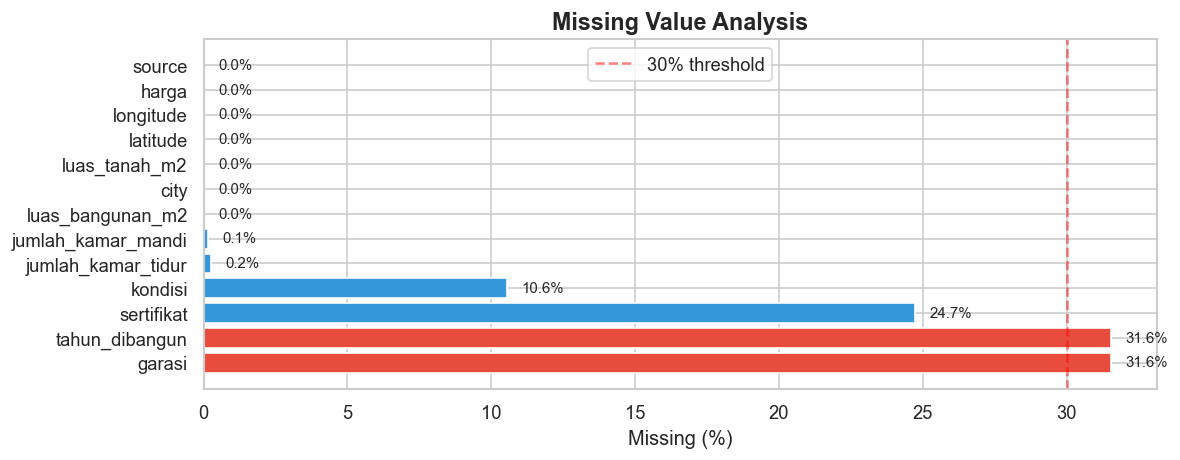

            column  missing_count   pct
            garasi           1383 31.55
    tahun_dibangun           1383 31.55
        sertifikat           1084 24.73
           kondisi            463 10.56
jumlah_kamar_tidur             11  0.25
jumlah_kamar_mandi              6  0.14
  luas_bangunan_m2              0  0.00
              city              0  0.00
     luas_tanah_m2              0  0.00
          latitude              0  0.00
         longitude              0  0.00
             harga              0  0.00
            source              0  0.00


In [79]:
# ─── 3.2 Missing Value Analysis ───────────────────────────────────────────────

missing = (
    df_all.isnull().sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)
missing["pct"] = (missing["missing_count"] / len(df_all) * 100).round(2)
missing = missing.sort_values("pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing["column"], missing["pct"],
               color=["#e74c3c" if p > 30 else "#3498db" for p in missing["pct"]])
ax.set_xlabel("Missing (%)")
ax.set_title("Missing Value Analysis", fontsize=14, fontweight="bold")
ax.axvline(30, ls="--", color="red", alpha=0.5, label="30% threshold")
ax.legend()
for bar, val in zip(bars, missing["pct"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(missing.to_string(index=False))

### 3.3 Target Variable Distribution

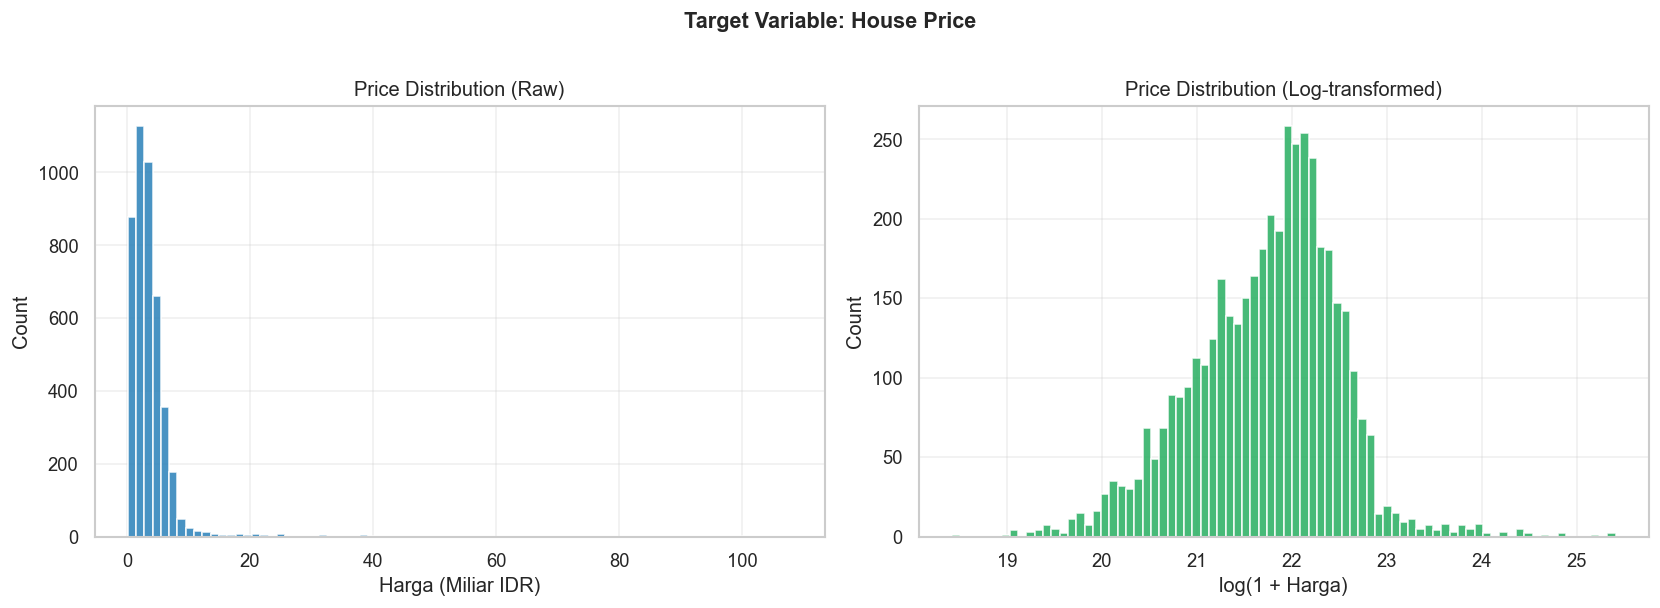

Skewness (raw)   : 10.925
Skewness (log)   : -0.235  ← much closer to normal


In [80]:
# ─── 3.3 Target Variable Distribution ────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price
axes[0].hist(df_all["harga"].dropna() / 1e9, bins=80,
             color="#2980b9", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Harga (Miliar IDR)")
axes[0].set_title("Price Distribution (Raw)")

# Log-transformed price
log_price = np.log1p(df_all["harga"].dropna())
axes[1].hist(log_price, bins=80, color="#27ae60", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("log(1 + Harga)")
axes[1].set_title("Price Distribution (Log-transformed)")

for ax in axes:
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)

plt.suptitle("Target Variable: House Price", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"Skewness (raw)   : {df_all['harga'].skew():.3f}")
print(f"Skewness (log)   : {log_price.skew():.3f}  ← much closer to normal")

### 3.4 Numerical Feature Distributions

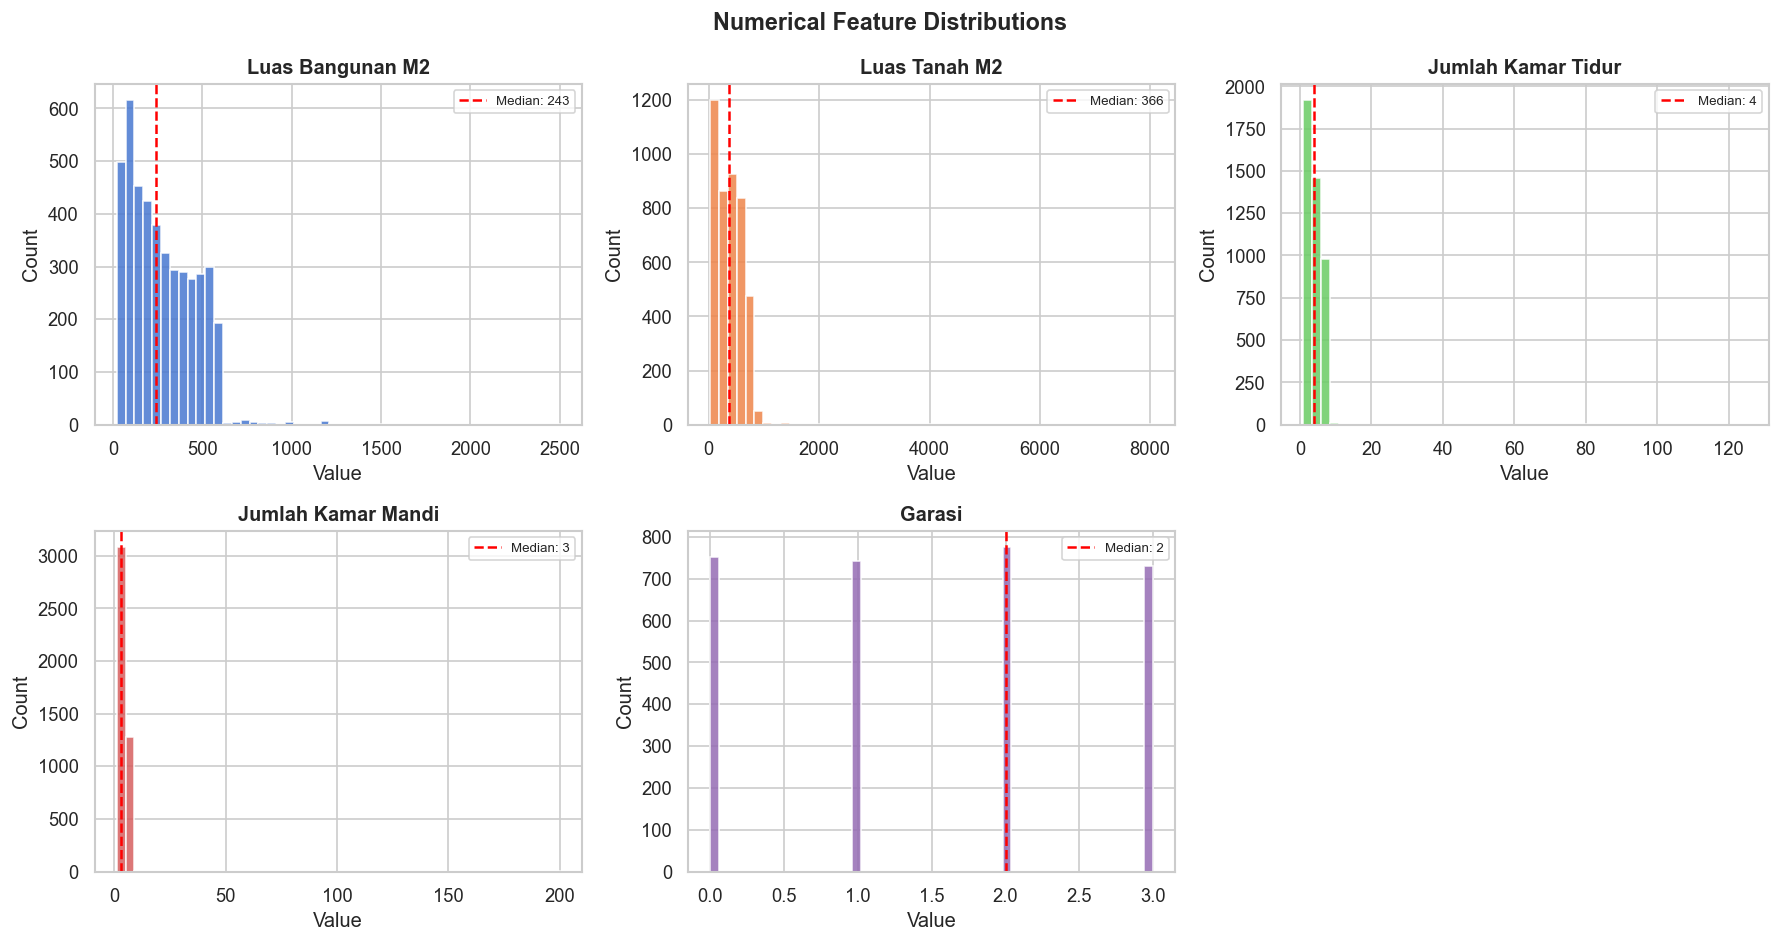

In [81]:
# ─── 3.4 Numerical Feature Distributions ─────────────────────────────────────

num_cols = ["luas_bangunan_m2", "luas_tanah_m2",
            "jumlah_kamar_tidur", "jumlah_kamar_mandi", "garasi"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = sns.color_palette("muted", len(num_cols))

for i, (col, color) in enumerate(zip(num_cols, colors)):
    data = df_all[col].dropna()
    axes[i].hist(data, bins=50, color=color, edgecolor="white", alpha=0.85)
    axes[i].set_title(col.replace("_", " ").title(), fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
    axes[i].axvline(data.median(), color="red", ls="--", lw=1.5, label=f"Median: {data.median():.0f}")
    axes[i].legend(fontsize=8)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.5 Categorical Feature Analysis

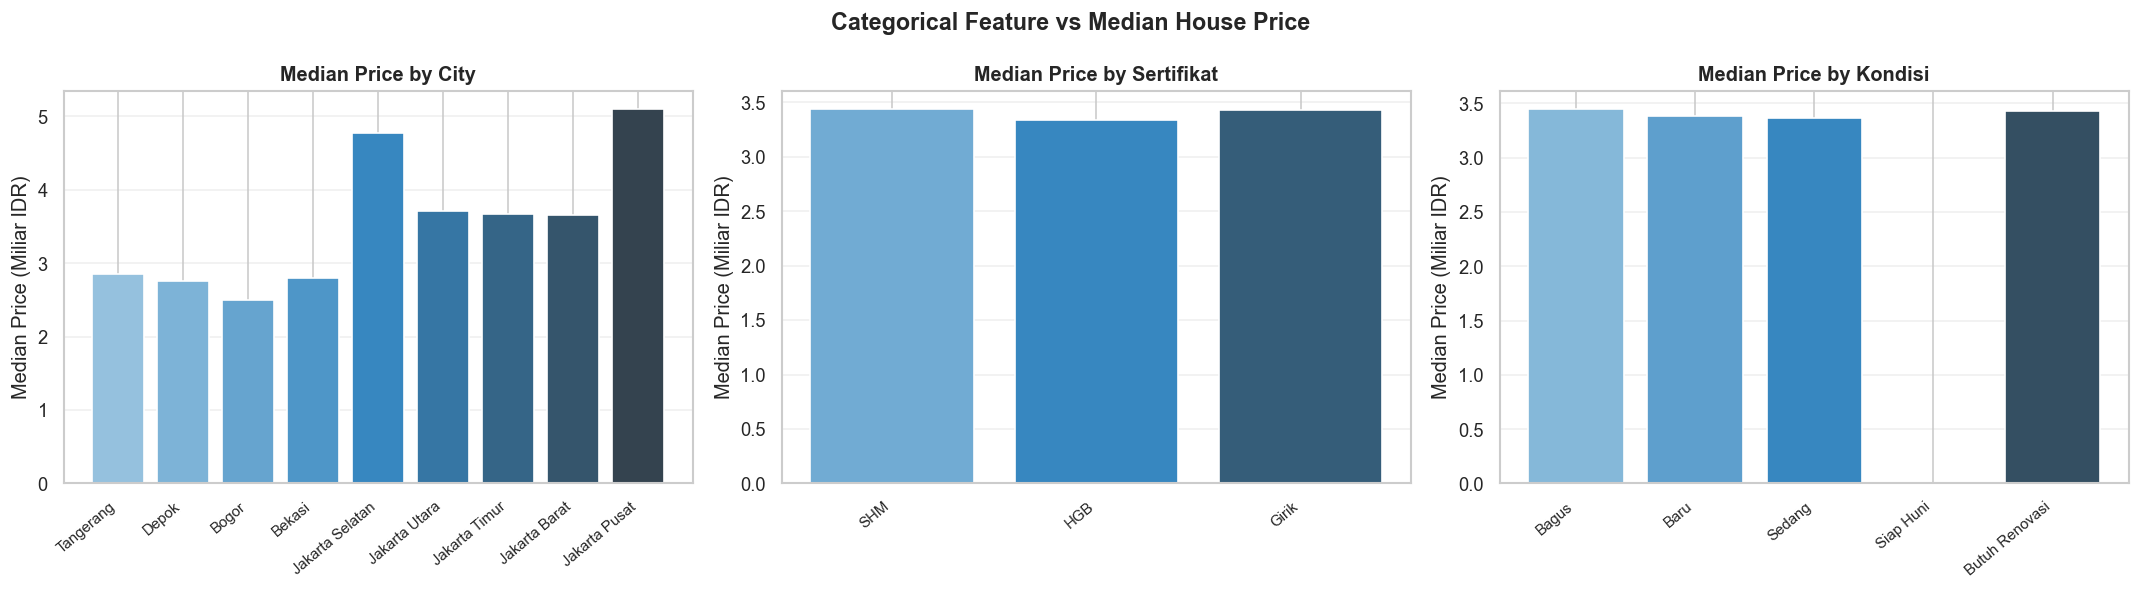

In [82]:
# ─── 3.5 Categorical Feature Analysis ────────────────────────────────────────

cat_cols = ["city", "sertifikat", "kondisi"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, cat_cols):
    order = df_all[col].value_counts().index
    median_by_cat = df_kaggle_copy.groupby(col)["harga"].median().reindex(order) / 1e9

    bars = ax.bar(range(len(order)), median_by_cat.values,
                  color=sns.color_palette("Blues_d", len(order)))
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=40, ha="right", fontsize=9)
    ax.set_ylabel("Median Price (Miliar IDR)")
    ax.set_title(f"Median Price by {col.replace('_', ' ').title()}",
                 fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Categorical Feature vs Median House Price", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.6 Geographic Price Heatmap

In [83]:
# ─── 3.6 Geographic Price Heatmap ────────────────────────────────────────────

df_geo = df_all.dropna(subset=["latitude", "longitude", "harga"]).copy()

# Center map on Jakarta
m = folium.Map(location=[-6.2088, 106.8456], zoom_start=11,
               tiles="CartoDB positron")

# HeatMap: weight each point by normalized log-price
log_p = np.log1p(df_geo["harga"])
weight = ((log_p - log_p.min()) / (log_p.max() - log_p.min())).tolist()

heat_data = [
    [row.latitude, row.longitude, w]
    for (_, row), w in zip(df_geo.iterrows(), weight)
]

HeatMap(heat_data, radius=12, blur=15, max_zoom=13).add_to(m)

# MRT station markers
for name, (lat, lon) in MRT_STATIONS.items():
    folium.CircleMarker(
        location=[lat, lon], radius=5,
        color="#e74c3c", fill=True, fill_color="#e74c3c",
        tooltip=f"🚇 {name}"
    ).add_to(m)

m.save(DATA_PROC / "price_heatmap.html")
print("Heatmap saved to data/processed/price_heatmap.html")

# Display inline (Jupyter)
m

Heatmap saved to data/processed/price_heatmap.html


### 3.7 Correlation Matrix

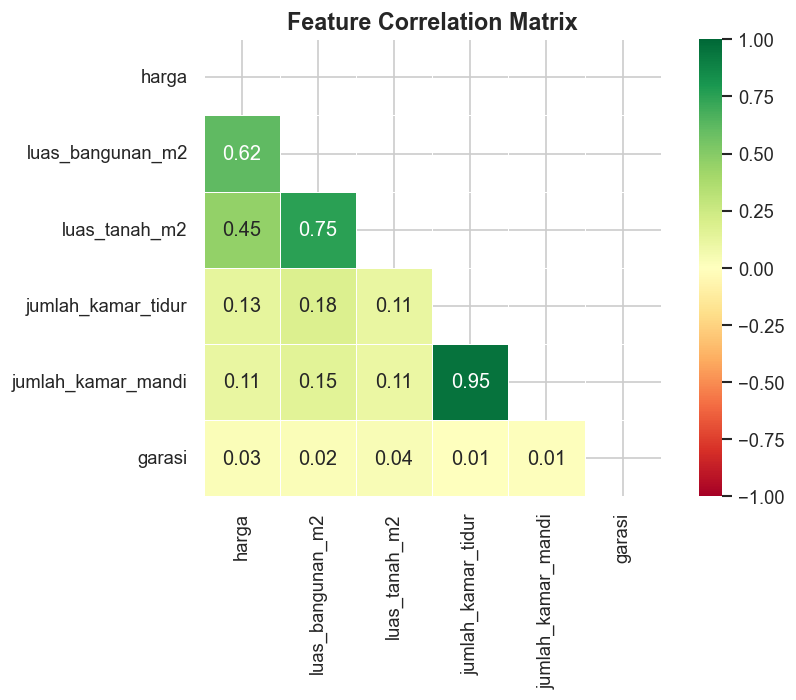

In [84]:
# ─── 3.7 Correlation Matrix ───────────────────────────────────────────────────

corr_cols = ["harga", "luas_bangunan_m2", "luas_tanah_m2",
             "jumlah_kamar_tidur", "jumlah_kamar_mandi", "garasi"]

corr = df_all[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, square=True,
    linewidths=0.5, ax=ax, vmin=-1, vmax=1
)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. Data Preprocessing

### 4.1 Handling Missing Values

In [85]:
# ─── 4.1 Handling Missing Values ─────────────────────────────────────────────

df = df_all.copy()

# Drop rows where the target (harga) is missing — we cannot impute a label
before = len(df)
df = df.dropna(subset=["harga"])
print(f"Dropped {before - len(df):,} rows with missing 'harga'  →  {len(df):,} rows remain")

# ── Numerical columns: fill with median (robust to outliers) ──────────────────
num_fill = ["luas_bangunan_m2", "luas_tanah_m2",
            "jumlah_kamar_tidur", "jumlah_kamar_mandi", "garasi", "tahun_dibangun"]

for col in num_fill:
    med = df[col].median()
    n_filled = df[col].isna().sum()
    df[col] = df[col].fillna(med)
    if n_filled:
        print(f"  {col:<30}: filled {n_filled:,} NaN  →  median = {med:.1f}")

# ── Categorical columns: fill with mode ───────────────────────────────────────
cat_fill = ["city", "sertifikat", "kondisi"]

for col in cat_fill:
    mode_val = df[col].mode()[0]
    n_filled = df[col].isna().sum()
    df[col] = df[col].fillna(mode_val)
    if n_filled:
        print(f"  {col:<30}: filled {n_filled:,} NaN  →  mode = '{mode_val}'")

# ── Geo coords: fill with city-level centroid ─────────────────────────────────
city_centroids = df.groupby("city")[["latitude", "longitude"]].transform("median")
df["latitude"]  = df["latitude"].fillna(city_centroids["latitude"])
df["longitude"] = df["longitude"].fillna(city_centroids["longitude"])

print(f"\nFinal missing counts:")
print(df[SHARED_COLS].isnull().sum()[df[SHARED_COLS].isnull().sum() > 0])

Dropped 0 rows with missing 'harga'  →  4,383 rows remain
  jumlah_kamar_tidur            : filled 11 NaN  →  median = 4.0
  jumlah_kamar_mandi            : filled 6 NaN  →  median = 3.0
  garasi                        : filled 1,383 NaN  →  median = 2.0
  tahun_dibangun                : filled 1,383 NaN  →  median = 2001.0
  sertifikat                    : filled 1,084 NaN  →  mode = 'SHM'
  kondisi                       : filled 463 NaN  →  mode = 'Bagus'

Final missing counts:
Series([], dtype: int64)


### 4.2 Outlier Detection & Treatment

We use the IQR fence method on the price column. Extreme outliers (luxury mansions with IDR 50B+) are capped rather than dropped — they carry valid signal.

In [86]:
# ─── 4.2 Outlier Detection & Treatment ───────────────────────────────────────

def iqr_bounds(series: pd.Series, k: float = 3.0):
    """
    Calculate IQR-based outlier fences.

    Parameters
    ----------
    series : pd.Series
    k      : float — multiplier (default 3.0 for extreme outliers only)

    Returns
    -------
    (lower, upper) fence values
    """
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR


# ── Price outliers ────────────────────────────────────────────────────────────
lo, hi = iqr_bounds(df["harga"], k=3.0)
n_outliers = ((df["harga"] < lo) | (df["harga"] > hi)).sum()
print(f"Price outliers (k=3): {n_outliers:,} rows")
print(f"  Lower fence : IDR {lo:,.0f}")
print(f"  Upper fence : IDR {hi:,.0f}")

# Cap rather than drop — preserves volume
df["harga"] = df["harga"].clip(lower=max(lo, 100_000_000), upper=hi)

# ── Physical dimension outliers (sanity check) ────────────────────────────────
# Building area > 2000 m² or < 15 m² is almost certainly a data entry error
df = df[(df["luas_bangunan_m2"] >= 15) & (df["luas_bangunan_m2"] <= 2000)]
df = df[(df["luas_tanah_m2"] >= 15) & (df["luas_tanah_m2"] <= 5000)]

# Sanity: land must be >= building
df = df[df["luas_tanah_m2"] >= df["luas_bangunan_m2"] * 0.8]

print(f"\nAfter outlier treatment  →  {len(df):,} rows remain")

Price outliers (k=3): 66 rows
  Lower fence : IDR -6,829,271,814
  Upper fence : IDR 13,015,690,578

After outlier treatment  →  3,936 rows remain


### 4.3 Data Type Casting

In [87]:
# ─── 4.3 Data Type Casting ────────────────────────────────────────────────────

df["jumlah_kamar_tidur"]  = df["jumlah_kamar_tidur"].astype(int)
df["jumlah_kamar_mandi"]  = df["jumlah_kamar_mandi"].astype(int)
df["garasi"]              = df["garasi"].astype(int)
df["tahun_dibangun"]      = df["tahun_dibangun"].astype(int)

df["city"]       = df["city"].astype("category")
df["sertifikat"] = df["sertifikat"].astype("category")
df["kondisi"]    = df["kondisi"].astype("category")

print("Dtypes after casting:")
print(df.dtypes)

Dtypes after casting:
city                  category
luas_bangunan_m2         int64
luas_tanah_m2            int64
jumlah_kamar_tidur       int64
jumlah_kamar_mandi       int64
garasi                   int64
tahun_dibangun           int64
sertifikat            category
kondisi               category
latitude               float64
longitude              float64
harga                  float64
source                  object
dtype: object


### 4.4 Target Variable Transformation (Log)

House prices are right-skewed. A log1p transform makes the distribution approximately normal, which benefits tree-based models by reducing the impact of large residuals and helps linear baselines significantly.

In [89]:
# ─── 4.4 Target Variable Transformation ──────────────────────────────────────

df["log_harga"] = np.log1p(df["harga"])

print(f"Original  — skewness: {df['harga'].skew():.3f}")
print(f"Log1p     — skewness: {df['log_harga'].skew():.3f}")

# Save clean dataset
df.to_csv(PROCESSED_CSV, index=False)
print(f"\nProcessed dataset saved → {PROCESSED_CSV}")

Original  — skewness: 1.366
Log1p     — skewness: -0.649

Processed dataset saved → D:\Analytic Projects 2026\Project Github\jakarta-house-predictor-system\data\processed\jabodetabek_houses.csv


---
## 5. Feature Engineering

### 5.1 MRT Station Proximity (Geopy)

Distance to the nearest MRT station is a strong predictor of urban property value in Jakarta, especially post-2019 Phase 1 launch. We compute geodesic distance (most accurate spherical Earth approximation) from each listing to the nearest station.

Computing MRT distances: 100%|████████████████████████████████████████████████████| 3936/3936 [00:18<00:00, 217.61it/s]


MRT distances computed.
  Min: 0.07 km
  Max: 47.79 km
  Median: 11.21 km


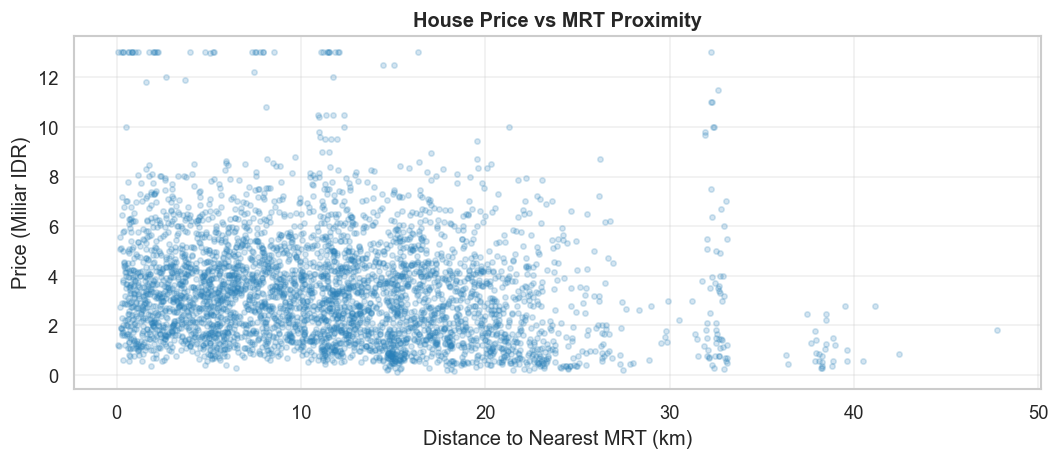

In [90]:
# ─── 5.1 MRT Station Proximity ────────────────────────────────────────────────

def min_mrt_distance_km(lat: float, lon: float) -> float:
    """
    Return the geodesic distance in km from (lat, lon) to the nearest
    Jakarta MRT station defined in MRT_COORDS.
    """
    point = (lat, lon)
    return min(geodesic(point, station).km for station in MRT_COORDS)


# Apply vectorized (still pure Python loop, but tqdm gives progress)
tqdm.pandas(desc="Computing MRT distances")

if "dist_mrt_km" not in df.columns:
    df["dist_mrt_km"] = df.progress_apply(
        lambda r: min_mrt_distance_km(r["latitude"], r["longitude"]),
        axis=1
    )
    print("MRT distances computed.")
else:
    print("MRT distances already present.")

print(f"  Min: {df['dist_mrt_km'].min():.2f} km")
print(f"  Max: {df['dist_mrt_km'].max():.2f} km")
print(f"  Median: {df['dist_mrt_km'].median():.2f} km")

# Scatter: distance vs price
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(df["dist_mrt_km"], df["harga"] / 1e9,
           alpha=0.2, s=10, color="#2980b9")
ax.set_xlabel("Distance to Nearest MRT (km)")
ax.set_ylabel("Price (Miliar IDR)")
ax.set_title("House Price vs MRT Proximity", fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Price per sqm Benchmark (for EDA only — not a feature)

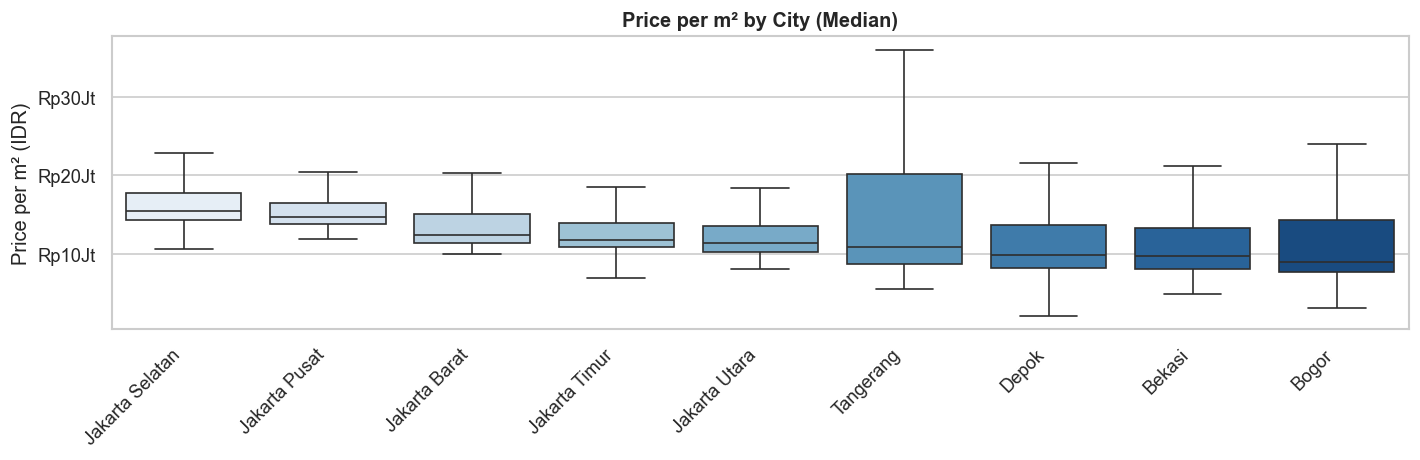

In [91]:
# ─── 5.2 Price per sqm Benchmark ─────────────────────────────────────────────
# Note: This is created for EDA insights only.
# We do NOT use price_per_m2 as a model feature — it would cause target leakage.

df["price_per_m2"] = df["harga"] / df["luas_bangunan_m2"]

fig, ax = plt.subplots(figsize=(12, 4))
order = df.groupby("city")["price_per_m2"].median().sort_values(ascending=False).index
sns.boxplot(
    data=df, x="city", y="price_per_m2",
    order=order, palette="Blues",
    showfliers=False, ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp{x/1e6:.0f}Jt"))
ax.set_title("Price per m² by City (Median)", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Price per m² (IDR)")
plt.tight_layout()
plt.show()

# Drop to avoid leakage
df.drop(columns=["price_per_m2"], inplace=True)

### 5.3 Room Ratio Features

In [92]:
# ─── 5.3 Room Ratio Features ──────────────────────────────────────────────────

# Bathroom-to-bedroom ratio: higher ratio → more luxurious
df["bath_bed_ratio"] = (
    df["jumlah_kamar_mandi"] / df["jumlah_kamar_tidur"].replace(0, 1)
)

# Area per bedroom: space efficiency
df["area_per_bed"] = (
    df["luas_bangunan_m2"] / df["jumlah_kamar_tidur"].replace(0, 1)
)

# Land coverage ratio: building / land (density indicator)
df["bcr"] = df["luas_bangunan_m2"] / df["luas_tanah_m2"].replace(0, 1)

# Total room count
df["total_rooms"] = df["jumlah_kamar_tidur"] + df["jumlah_kamar_mandi"]

print("New room-ratio features created:")
print(df[["bath_bed_ratio", "area_per_bed", "bcr", "total_rooms"]].describe())

New room-ratio features created:
       bath_bed_ratio  area_per_bed      bcr  total_rooms
count        3,936.00      3,936.00 3,936.00     3,936.00
mean             0.85         96.93     0.71         7.34
std              0.20        105.02     0.22         4.46
min              0.25          5.14     0.05         2.00
25%              0.75         32.67     0.57         4.00
50%              0.86         62.58     0.71         7.00
75%              1.00        112.06     0.86        10.00
max              5.00        596.00     1.25       160.00


### 5.4 Property Age & Condition Encoding

In [93]:
# ─── 5.4 Property Age & Condition Encoding ────────────────────────────────────

CURRENT_YEAR = 2025

# Property age in years
df["property_age"] = CURRENT_YEAR - df["tahun_dibangun"]
df["property_age"] = df["property_age"].clip(lower=0)  # guard against future dates

# Age bucket: new / modern / mature / old
df["age_bucket"] = pd.cut(
    df["property_age"],
    bins=[-1, 5, 15, 30, 200],
    labels=["New (<5yr)", "Modern (5-15yr)", "Mature (15-30yr)", "Old (>30yr)"]
)

# Condition ordinal encoding (worst → best)
KONDISI_ORDER = {"Butuh Renovasi": 0, "Sedang": 1, "Bagus": 2, "Baru": 3}
df["kondisi_enc"] = df["kondisi"].map(KONDISI_ORDER).fillna(1).astype(int)

# Certificate ordinal (SHM = strongest ownership rights)
CERT_ORDER = {"Girik": 0, "HGB": 1, "SHM": 2}
df["cert_enc"] = df["sertifikat"].map(CERT_ORDER).fillna(1).astype(int)

print(df[["property_age", "age_bucket", "kondisi_enc", "cert_enc"]].head(5))

   property_age        age_bucket  kondisi_enc  cert_enc
0            25  Mature (15-30yr)            1         2
1            10   Modern (5-15yr)            3         2
2             6   Modern (5-15yr)            2         2
3            27  Mature (15-30yr)            1         1
4            34       Old (>30yr)            2         2


### 5.5 Regional Zone Encoding

In [94]:
# ─── 5.5 Regional Zone Encoding ───────────────────────────────────────────────

# Map cities to broader regional zones — captures macro economic gradients
ZONE_MAP = {
    "Jakarta Selatan" : "Jakarta Core",
    "Jakarta Pusat"   : "Jakarta Core",
    "Jakarta Barat"   : "Jakarta Outer",
    "Jakarta Timur"   : "Jakarta Outer",
    "Jakarta Utara"   : "Jakarta Outer",
    "Depok"           : "Satellite South",
    "Bogor"           : "Satellite South",
    "Tangerang"       : "Satellite West",
    "Tangerang Selatan": "Satellite West",
    "Bekasi"          : "Satellite East",
}

df["zone"] = df["city"].map(ZONE_MAP).fillna("Other")

# One-hot encode zone
df = pd.get_dummies(df, columns=["zone"], prefix="zone", drop_first=True)

print("Zone columns:", [c for c in df.columns if c.startswith("zone_")])
print(df[["city"] + [c for c in df.columns if c.startswith("zone_")]].head(5))

Zone columns: ['zone_Jakarta Outer', 'zone_Satellite East', 'zone_Satellite South', 'zone_Satellite West']
            city  zone_Jakarta Outer  zone_Satellite East  \
0          Depok               False                False   
1  Jakarta Utara                True                False   
2      Tangerang               False                False   
3  Jakarta Pusat               False                False   
4          Depok               False                False   

   zone_Satellite South  zone_Satellite West  
0                  True                False  
1                 False                False  
2                 False                 True  
3                 False                False  
4                  True                False  


### 5.6 Final Feature Set Summary

In [97]:
# ─── 5.6 Final Feature Set Summary ───────────────────────────────────────────

# Define features to use in modeling
FEATURES_NUM = [
    "luas_bangunan_m2",
    "luas_tanah_m2",
    "jumlah_kamar_tidur",
    "jumlah_kamar_mandi",
    "garasi",
    "property_age",
    "dist_mrt_km",
    "bath_bed_ratio",
    "area_per_bed",
    "bcr",
    "total_rooms",
    "kondisi_enc",
    "cert_enc",
    "latitude",
    "longitude",
]

FEATURES_CAT = ["city"]   # handled by OrdinalEncoder in the pipeline

FEATURES_OHE = [c for c in df.columns if c.startswith("zone_")]  # already encoded

ALL_FEATURES = FEATURES_NUM + FEATURES_CAT + FEATURES_OHE
TARGET       = "log_harga"

print(f"Total features: {len(ALL_FEATURES)}")
print(f"  Numerical  : {len(FEATURES_NUM)}")
print(f"  Categorical: {len(FEATURES_CAT)}")
print(f"  Zone OHE   : {len(FEATURES_OHE)}")
print(f"  Target     : {TARGET}")

# Save feature metadata
META = {
    "features_num"  : FEATURES_NUM,
    "features_cat"  : FEATURES_CAT,
    "features_ohe"  : FEATURES_OHE,
    "all_features"  : ALL_FEATURES,
    "target"        : TARGET,
    "kondisi_order" : KONDISI_ORDER,
    "cert_order"    : CERT_ORDER,
    "zone_map"      : ZONE_MAP,
    "mrt_stations"  : MRT_STATIONS,
    "current_year"  : CURRENT_YEAR,
    "cities"        : df["city"].astype(str).unique().tolist(),
}
with open(META_PATH, "w") as f:
    json.dump(META, f, indent=2)
print(f"\nFeature metadata saved → {META_PATH}")

Total features: 20
  Numerical  : 15
  Categorical: 1
  Zone OHE   : 4
  Target     : log_harga

Feature metadata saved → D:\Analytic Projects 2026\Project Github\jakarta-house-predictor-system\models\feature_metadata.json


---
## 6. Model Training

### 6.1 Train / Validation / Test Split

We use an 70/15/15 split. The test set is held out entirely until Section 8 — evaluation.

In [98]:
# ─── 6.1 Train / Validation / Test Split ─────────────────────────────────────

# Confirm all features are present
missing_feats = [f for f in ALL_FEATURES if f not in df.columns]
if missing_feats:
    raise ValueError(f"Missing features in DataFrame: {missing_feats}")

X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

# First split: 70% train+val, 30% temp
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE
)

# Second split: from 85%, carve out 15% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,  # ~15% of total
    random_state=RANDOM_STATE
)

print(f"Train      : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation : {len(X_val):,} rows  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test       : {len(X_test):,} rows  ({len(X_test)/len(X)*100:.1f}%)")

Train      : 2,754 rows  (70.0%)
Validation : 591 rows  (15.0%)
Test       : 591 rows  (15.0%)


### 6.2 Preprocessing Pipeline

All preprocessing steps are encapsulated in a `sklearn.Pipeline` object so they can be serialized alongside the model and applied consistently at inference time.

In [99]:
# ─── 6.2 Preprocessing Pipeline ──────────────────────────────────────────────

# ── Numerical transformer ─────────────────────────────────────────────────────
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# ── Categorical transformer ───────────────────────────────────────────────────
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )),
])

# ── Passthrough for already-encoded zone OHE columns ─────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer,  FEATURES_NUM),
        ("cat", cat_transformer,  FEATURES_CAT),
        ("ohe", "passthrough",    FEATURES_OHE),
    ],
    remainder="drop"
)

# Fit on training data only
preprocessor.fit(X_train)

X_train_t = preprocessor.transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

print(f"Preprocessed shape: {X_train_t.shape}")

# Save pipeline now
joblib.dump(preprocessor, PIPELINE_PATH)
print(f"Pipeline saved → {PIPELINE_PATH}")

Preprocessed shape: (2754, 20)
Pipeline saved → D:\Analytic Projects 2026\Project Github\jakarta-house-predictor-system\models\preprocessing_pipeline.pkl


### 6.3 Baseline: Ridge Regression

A linear baseline establishes the minimum acceptable performance. Any worthwhile ML model should comfortably beat this.

In [100]:
# ─── 6.3 Baseline: Ridge Regression ──────────────────────────────────────────

def evaluate(model, X, y_true_log, name="Model"):
    y_pred_log = model.predict(X)

    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_true_log)

    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = root_mean_squared_error(y_true, y_pred)   # ← fix di sini
    r2    = r2_score(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100

    print(f"\n{name}")
    print(f"  MAE  : IDR {mae:>16,.0f}")
    print(f"  RMSE : IDR {rmse:>16,.0f}")
    print(f"  MAPE : {mape:>8.2f}%")
    print(f"  R²   : {r2:>8.4f}")

    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}


ridge = Ridge(alpha=1.0)
ridge.fit(X_train_t, y_train)

results = []
results.append(evaluate(ridge, X_val_t, y_val, name="Ridge (Baseline)"))


Ridge (Baseline)
  MAE  : IDR    4,136,601,113
  RMSE : IDR   83,833,367,654
  MAPE :    48.34%
  R²   : -1455.3217


### 6.4 XGBoost

In [101]:
# ─── 6.4 XGBoost ─────────────────────────────────────────────────────────────

xgb_model = xgb.XGBRegressor(**XGB_DEFAULTS)

xgb_model.fit(
    X_train_t, y_train,
    eval_set=[(X_val_t, y_val)],
    verbose=False
)

results.append(evaluate(xgb_model, X_val_t, y_val, name="XGBoost (default)"))


XGBoost (default)
  MAE  : IDR      284,740,707
  RMSE : IDR      644,019,906
  MAPE :    11.28%
  R²   :   0.9141


### 6.5 LightGBM

In [102]:
# ─── 6.5 LightGBM ────────────────────────────────────────────────────────────

lgb_model = lgb.LGBMRegressor(**LGB_DEFAULTS)

lgb_model.fit(
    X_train_t, y_train,
    eval_set=[(X_val_t, y_val)]
)

results.append(evaluate(lgb_model, X_val_t, y_val, name="LightGBM (default)"))


LightGBM (default)
  MAE  : IDR      316,168,701
  RMSE : IDR      657,191,691
  MAPE :    12.28%
  R²   :   0.9105


### 6.6 Hyperparameter Tuning with Optuna

We run a 50-trial Optuna study for both XGBoost and LightGBM. Optuna uses Tree-Structured Parzen Estimator (TPE) — a Bayesian optimization method — to efficiently explore the hyperparameter space.

In [103]:
# ─── 6.6 Hyperparameter Tuning — XGBoost ─────────────────────────────────────

def objective_xgb(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth"        : trial.suggest_int("max_depth", 3, 10),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "min_child_weight" : trial.suggest_int("min_child_weight", 1, 20),
        "random_state"     : RANDOM_STATE,
        "n_jobs"           : -1,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train_t, y_train, verbose=False)
    preds = model.predict(X_val_t)
    return np.sqrt(mean_squared_error(y_val, preds))  # ← fix: hapus squared=False


print("Tuning XGBoost (50 trials)...")
study_xgb = optuna.create_study(direction="minimize",
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print(f"\nBest XGBoost val RMSE (log-space): {study_xgb.best_value:.6f}")
print(f"Best params: {study_xgb.best_params}")

# Re-train with best params
best_xgb = xgb.XGBRegressor(
    **study_xgb.best_params, random_state=RANDOM_STATE, n_jobs=-1
)
best_xgb.fit(X_train_t, y_train, verbose=False)
results.append(evaluate(best_xgb, X_val_t, y_val, name="XGBoost (tuned)"))

Tuning XGBoost (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best XGBoost val RMSE (log-space): 0.187313
Best params: {'n_estimators': 747, 'learning_rate': 0.08124045252474203, 'max_depth': 7, 'subsample': 0.550111015852093, 'colsample_bytree': 0.5531980471507354, 'reg_alpha': 2.5494136943269954, 'reg_lambda': 0.00042915427872514177, 'min_child_weight': 7}

XGBoost (tuned)
  MAE  : IDR      291,642,228
  RMSE : IDR      639,183,015
  MAPE :    11.15%
  R²   :   0.9153


In [104]:
# ─── 6.6 (cont.) Hyperparameter Tuning — LightGBM ────────────────────────────

def objective_lgb(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves", 20, 300),
        "max_depth"        : trial.suggest_int("max_depth", 3, 15),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "random_state"     : RANDOM_STATE,
        "n_jobs"           : -1,
        "verbose"          : -1,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train_t, y_train)
    preds = model.predict(X_val_t)
    return np.sqrt(mean_squared_error(y_val, preds))  # ← fix: hapus squared=False


print("Tuning LightGBM (50 trials)...")
study_lgb = optuna.create_study(direction="minimize",
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(objective_lgb, n_trials=50, show_progress_bar=True)

print(f"\nBest LightGBM val RMSE (log-space): {study_lgb.best_value:.6f}")
print(f"Best params: {study_lgb.best_params}")

best_lgb = lgb.LGBMRegressor(
    **study_lgb.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
best_lgb.fit(X_train_t, y_train)
results.append(evaluate(best_lgb, X_val_t, y_val, name="LightGBM (tuned)"))

# Select best model
df_results = pd.DataFrame(results)
best_model_name = df_results.loc[df_results["RMSE"].idxmin(), "model"]
best_model = best_xgb if "XGBoost" in best_model_name else best_lgb
print(f"\n🏆 Best model on validation: {best_model_name}")

Tuning LightGBM (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best LightGBM val RMSE (log-space): 0.186038
Best params: {'n_estimators': 429, 'learning_rate': 0.08424629949259857, 'num_leaves': 300, 'max_depth': 13, 'subsample': 0.8666764305666824, 'colsample_bytree': 0.8523776661049296, 'reg_alpha': 0.00036948659381138204, 'reg_lambda': 1.6527405047219013, 'min_child_samples': 85}

LightGBM (tuned)
  MAE  : IDR      316,122,125
  RMSE : IDR      613,861,253
  MAPE :    11.93%
  R²   :   0.9219

🏆 Best model on validation: LightGBM (tuned)


---
## 7. Experiment Tracking with MLflow

### 7.1 MLflow Setup

After done executing below code, open http://127.0.0.1:5000 on your browser

In [105]:
# ─── 7.1 MLflow Setup ─────────────────────────────────────────────────────────

# Fix untuk Windows: pakai .as_uri() supaya format path benar
# file://D:\path → file:///D:/path  (3 slash, forward slash)
mlflow.set_tracking_uri(MLFLOW_URI.resolve().as_uri())

EXPERIMENT_NAME = "jakarta_house_price"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment          : {EXPERIMENT_NAME}")
print("\nTo launch the UI, run in terminal:")
print(f"  mlflow ui --backend-store-uri {MLFLOW_URI.resolve().as_uri()}")

MLflow tracking URI : file:///D:/Analytic%20Projects%202026/Project%20Github/jakarta-house-predictor-system/mlruns
Experiment          : jakarta_house_price

To launch the UI, run in terminal:
  mlflow ui --backend-store-uri file:///D:/Analytic%20Projects%202026/Project%20Github/jakarta-house-predictor-system/mlruns


### 7.2 Log All Experiments

In [106]:
# ─── 7.2 Log All Experiments ──────────────────────────────────────────────────

def log_run(model, model_name: str, params: dict, X_eval, y_eval_log, tags=None):
    """
    Log a model run to MLflow including params, metrics, and the model artifact.

    Parameters
    ----------
    model      : trained estimator
    model_name : display name for this run
    params     : hyperparameter dict to log
    X_eval     : preprocessed evaluation features
    y_eval_log : log-space evaluation targets
    tags       : optional dict of MLflow tags
    """
    with mlflow.start_run(run_name=model_name):
        # ── Log parameters ────────────────────────────────────────────────────
        mlflow.log_params(params)

        # ── Compute metrics ───────────────────────────────────────────────────
        y_pred_log = model.predict(X_eval)
        y_pred = np.expm1(y_pred_log)
        y_true = np.expm1(y_eval_log)

        metrics = {
            "val_mae"     : mean_absolute_error(y_true, y_pred),
            "val_rmse"    : np.sqrt(mean_squared_error(y_true, y_pred)),        # ← fix
            "val_r2"      : r2_score(y_true, y_pred),
            "val_mape"    : float(np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100),
            "val_rmse_log": float(np.sqrt(mean_squared_error(y_eval_log, y_pred_log))),  # ← fix
}
        mlflow.log_metrics(metrics)

        # ── Log model ─────────────────────────────────────────────────────────
        if isinstance(model, xgb.XGBRegressor):
            mlflow.xgboost.log_model(model, artifact_path="model")
        elif isinstance(model, lgb.LGBMRegressor):
            mlflow.lightgbm.log_model(model, artifact_path="model")
        else:
            mlflow.sklearn.log_model(model, artifact_path="model")

        # ── Tags ──────────────────────────────────────────────────────────────
        mlflow.set_tag("project", "jakarta_house_price")
        mlflow.set_tag("author",  "portfolio")
        if tags:
            for k, v in tags.items():
                mlflow.set_tag(k, v)

        print(f"  ✓ Logged: {model_name}  |  RMSE: IDR {metrics['val_rmse']:,.0f}  |  R²: {metrics['val_r2']:.4f}")


print("Logging runs to MLflow...")

log_run(ridge,    "Ridge Baseline",    {"alpha": 1.0},
        X_val_t, y_val, tags={"model_type": "linear"})

log_run(xgb_model, "XGBoost Default",  XGB_DEFAULTS,
        X_val_t, y_val, tags={"model_type": "xgboost"})

log_run(lgb_model, "LightGBM Default", LGB_DEFAULTS,
        X_val_t, y_val, tags={"model_type": "lightgbm"})

log_run(best_xgb,  "XGBoost Tuned",    study_xgb.best_params,
        X_val_t, y_val, tags={"model_type": "xgboost", "tuned": "true"})

log_run(best_lgb,  "LightGBM Tuned",   study_lgb.best_params,
        X_val_t, y_val, tags={"model_type": "lightgbm", "tuned": "true"})

print("\nAll runs logged.")

2026/04/19 16:09:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logging runs to MLflow...


2026/04/19 16:09:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/19 16:09:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  ✓ Logged: Ridge Baseline  |  RMSE: IDR 83,833,367,654  |  R²: -1455.3217


2026/04/19 16:09:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

  ✓ Logged: LightGBM Default  |  RMSE: IDR 657,191,691  |  R²: 0.9105


2026/04/19 16:10:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  ✓ Logged: XGBoost Tuned  |  RMSE: IDR 639,183,015  |  R²: 0.9153


2026/04/19 16:10:14 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ Logged: LightGBM Tuned  |  RMSE: IDR 613,861,253  |  R²: 0.9219

All runs logged.


### 7.3 Compare Runs

In [108]:
# ─── 7.3 Compare Runs ─────────────────────────────────────────────────────────

runs_df = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=["metrics.val_rmse ASC"]
)

display_cols = ["tags.mlflow.runName", "metrics.val_rmse",
                "metrics.val_mae", "metrics.val_mape", "metrics.val_r2"]
display_cols = [c for c in display_cols if c in runs_df.columns]

runs_df[display_cols].rename(columns={
    "tags.mlflow.runName" : "Run",
    "metrics.val_rmse"    : "RMSE (IDR)",
    "metrics.val_mae"     : "MAE (IDR)",
    "metrics.val_mape"    : "MAPE (%)",
    "metrics.val_r2"      : "R²",
}).style.format({
    "RMSE (IDR)": "{:,.0f}",
    "MAE (IDR)" : "{:,.0f}",
    "MAPE (%)"  : "{:.2f}",
    "R²"        : "{:.4f}",
}).highlight_min(subset=["RMSE (IDR)"], color="lightgreen")

,Run,RMSE (IDR),MAE (IDR),MAPE (%),R²
0,LightGBM Tuned,"171,002,442","137,143,091",4.77,0.9904
1,XGBoost Tuned,"174,676,388","139,105,049",4.74,0.9900
2,XGBoost Default,"178,091,220","142,682,204",5.10,0.9896
3,LightGBM Default,"184,176,701","145,367,543",5.15,0.9889
4,Ridge Baseline,"413,369,190","297,135,971",8.99,0.9442
5,LightGBM Tuned,"613,861,253","316,122,125",11.93,0.9219
6,XGBoost Tuned,"639,183,015","291,642,228",11.15,0.9153
7,XGBoost Default,"644,019,906","284,740,707",11.28,0.9141
8,LightGBM Default,"657,191,691","316,168,701",12.28,0.9105
9,Ridge Baseline,"83,833,367,654","4,136,601,113",48.34,-1455.3217


---
## 8. Model Evaluation

### 8.1 Evaluation Metrics on Held-Out Test Set

We now evaluate the best model on the untouched test set.

In [109]:
# ─── 8.1 Final Evaluation on Test Set ────────────────────────────────────────

test_result = evaluate(best_model, X_test_t, y_test, name=f"Best Model ({best_model_name}) — TEST SET")

print("\n" + "=" * 55)
print(f"  FINAL TEST SET PERFORMANCE")
print(f"  MAE  : IDR {test_result['MAE']:>15,.0f}")
print(f"  RMSE : IDR {test_result['RMSE']:>15,.0f}")
print(f"  MAPE :      {test_result['MAPE']:>10.2f}%")
print(f"  R²   :      {test_result['R2']:>10.4f}")
print("=" * 55)


Best Model (LightGBM (tuned)) — TEST SET
  MAE  : IDR      323,410,016
  RMSE : IDR      574,087,384
  MAPE :    12.83%
  R²   :   0.9267

  FINAL TEST SET PERFORMANCE
  MAE  : IDR     323,410,016
  RMSE : IDR     574,087,384
  MAPE :           12.83%
  R²   :          0.9267


### 8.2 Prediction vs Actual Plot

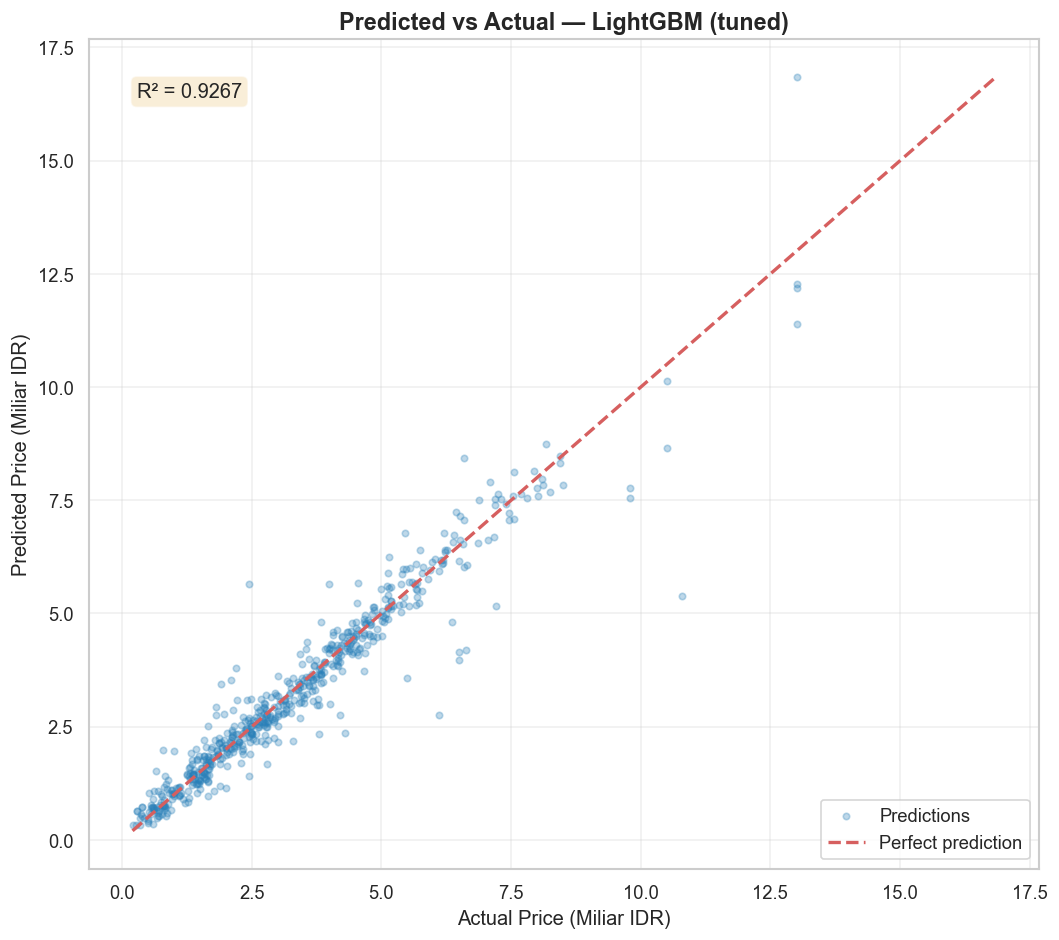

In [110]:
# ─── 8.2 Prediction vs Actual Plot ───────────────────────────────────────────

y_pred_test = np.expm1(best_model.predict(X_test_t))
y_true_test = np.expm1(y_test.values)

fig, ax = plt.subplots(figsize=(9, 8))

ax.scatter(y_true_test / 1e9, y_pred_test / 1e9,
           alpha=0.3, s=15, color="#2980b9", label="Predictions")

# Perfect prediction line
lims = [
    min(y_true_test.min(), y_pred_test.min()) / 1e9,
    max(y_true_test.max(), y_pred_test.max()) / 1e9,
]
ax.plot(lims, lims, "r--", lw=2, label="Perfect prediction")

ax.set_xlabel("Actual Price (Miliar IDR)", fontsize=12)
ax.set_ylabel("Predicted Price (Miliar IDR)", fontsize=12)
ax.set_title(f"Predicted vs Actual — {best_model_name}", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.93, f"R² = {test_result['R2']:.4f}", transform=ax.transAxes,
        fontsize=12, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()

### 8.3 Residual Analysis

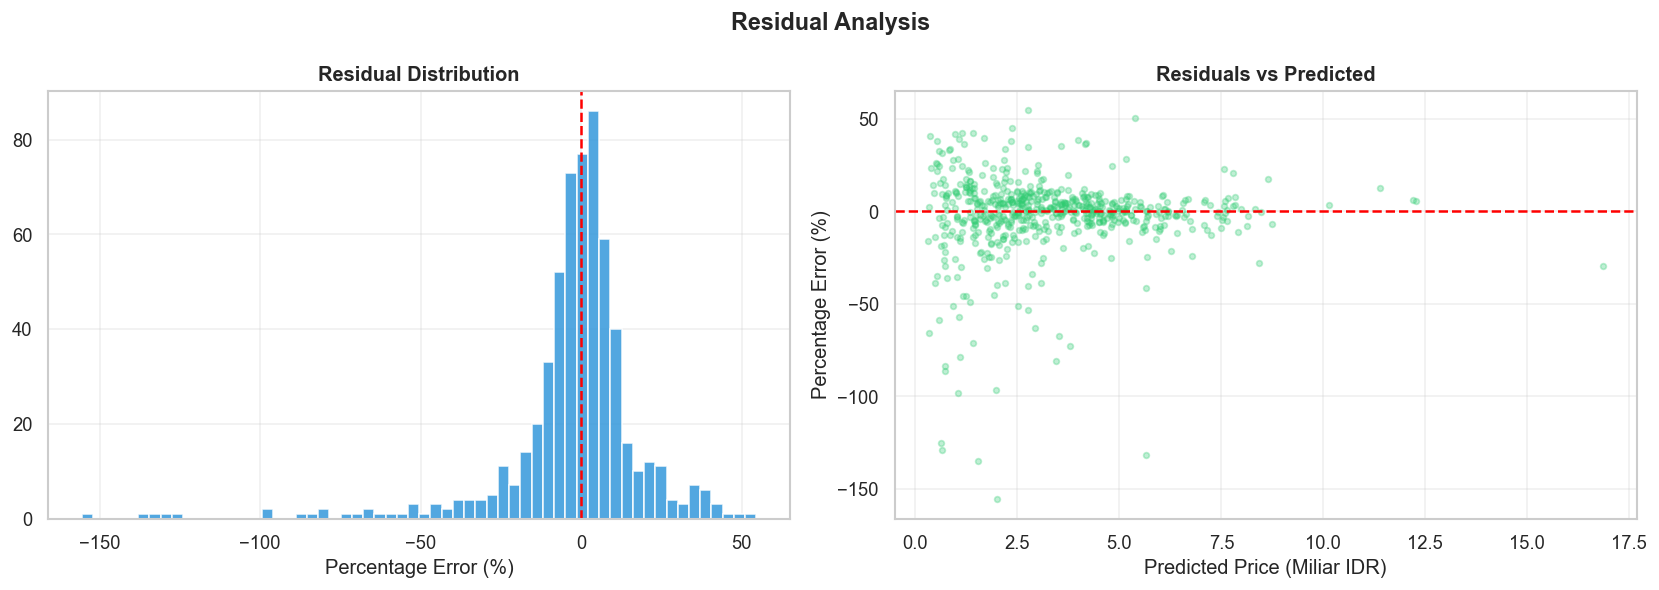

Mean percentage error  : -2.26%  (bias)
Std percentage error   : 22.21%
Predictions within 20% : 82.1% of listings


In [111]:
# ─── 8.3 Residual Analysis ────────────────────────────────────────────────────

residuals = y_true_test - y_pred_test
pct_err   = residuals / y_true_test * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
axes[0].hist(pct_err, bins=60, color="#3498db", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="red", ls="--", lw=1.5)
axes[0].set_xlabel("Percentage Error (%)")
axes[0].set_title("Residual Distribution", fontweight="bold")

# Residuals vs predicted
axes[1].scatter(y_pred_test / 1e9, pct_err, alpha=0.3, s=12, color="#2ecc71")
axes[1].axhline(0, color="red", ls="--", lw=1.5)
axes[1].set_xlabel("Predicted Price (Miliar IDR)")
axes[1].set_ylabel("Percentage Error (%)")
axes[1].set_title("Residuals vs Predicted", fontweight="bold")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle("Residual Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Mean percentage error  : {pct_err.mean():.2f}%  (bias)")
print(f"Std percentage error   : {pct_err.std():.2f}%")
print(f"Predictions within 20% : {(np.abs(pct_err) <= 20).mean()*100:.1f}% of listings")

### 8.4 Model Comparison Summary

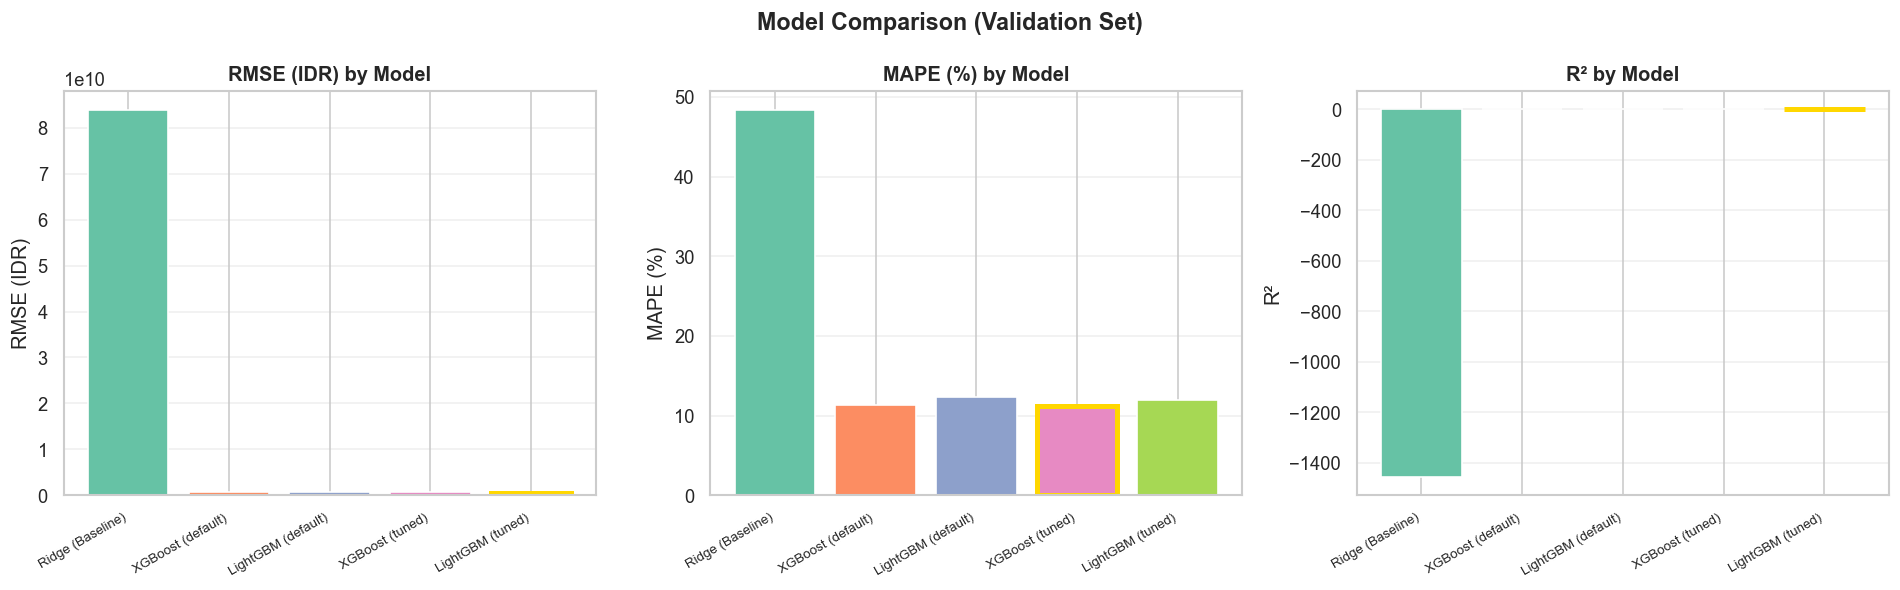

,model,MAE,RMSE,MAPE,R2
4,LightGBM (tuned),"316,122,125.29","613,861,253.07",11.93,0.92
3,XGBoost (tuned),"291,642,228.48","639,183,014.60",11.15,0.92
1,XGBoost (default),"284,740,706.76","644,019,906.04",11.28,0.91
2,LightGBM (default),"316,168,700.52","657,191,690.81",12.28,0.91
0,Ridge (Baseline),"4,136,601,112.84","83,833,367,654.23",48.34,"-1,455.32"


In [112]:
# ─── 8.4 Model Comparison Summary ────────────────────────────────────────────

df_comp = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = [("RMSE", "RMSE (IDR)", True), ("MAPE", "MAPE (%)", True), ("R2", "R²", False)]
colors = sns.color_palette("Set2", len(df_comp))

for ax, (metric, label, lower_is_better) in zip(axes, metrics_to_plot):
    vals = df_comp[metric]
    bars = ax.bar(df_comp["model"], vals, color=colors)
    best_idx = vals.idxmin() if lower_is_better else vals.idxmax()
    bars[best_idx].set_edgecolor("gold")
    bars[best_idx].set_linewidth(3)
    ax.set_ylabel(label)
    ax.set_title(f"{label} by Model", fontweight="bold")
    ax.set_xticklabels(df_comp["model"], rotation=30, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Model Comparison (Validation Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

df_comp.sort_values("RMSE")

---
## 9. SHAP Explainability

SHAP (SHapley Additive exPlanations) provides unified, game-theory-based explanations for any ML model. It answers: *"How much did each feature contribute to this specific prediction?"*

### 9.1 Global Feature Importance (Summary Plot)

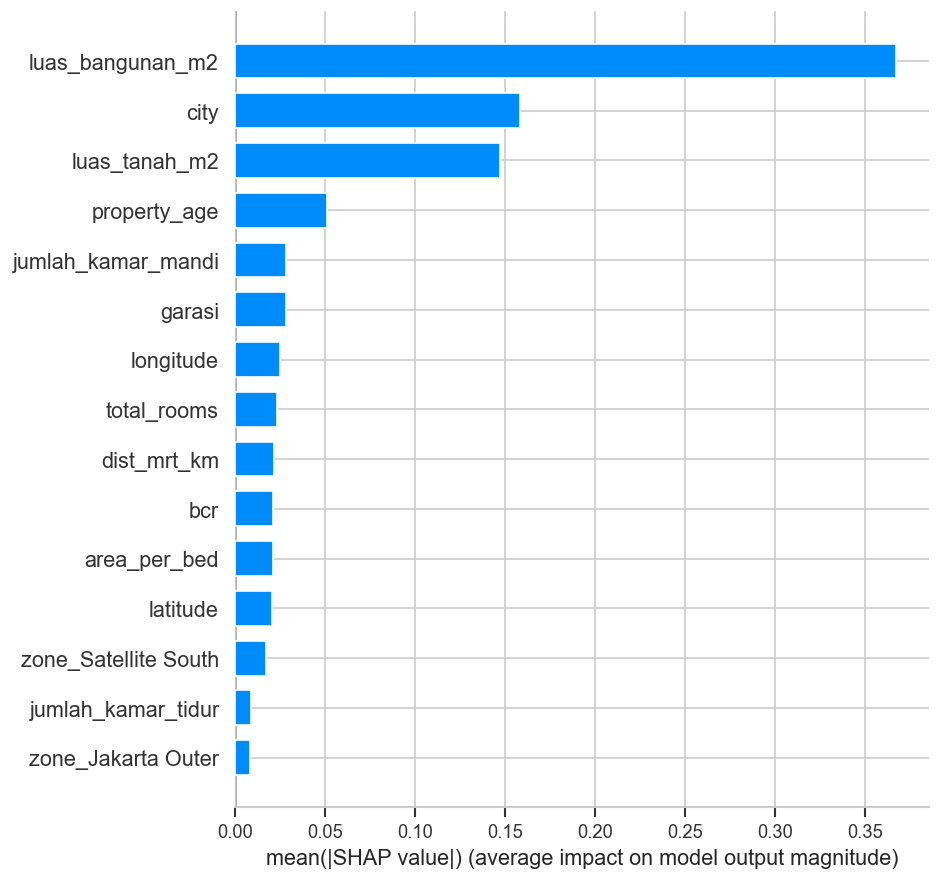

In [113]:
# ─── 9.1 SHAP — Setup & Global Summary ───────────────────────────────────────

# Use TreeExplainer — optimized for gradient boosting models
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values on the test set (can be slow for large sets — sample if needed)
SHAP_SAMPLE = min(500, len(X_test_t))  # cap at 500 for speed
idx_sample  = np.random.choice(len(X_test_t), SHAP_SAMPLE, replace=False)
X_shap      = X_test_t[idx_sample]

shap_values = explainer.shap_values(X_shap)

# Feature names after preprocessing
feature_names_transformed = FEATURES_NUM + FEATURES_CAT + FEATURES_OHE

# Bar plot — mean |SHAP| across all predictions
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_names_transformed,
    plot_type="bar",
    max_display=15,
    show=True
)

### 9.2 SHAP Beeswarm Plot

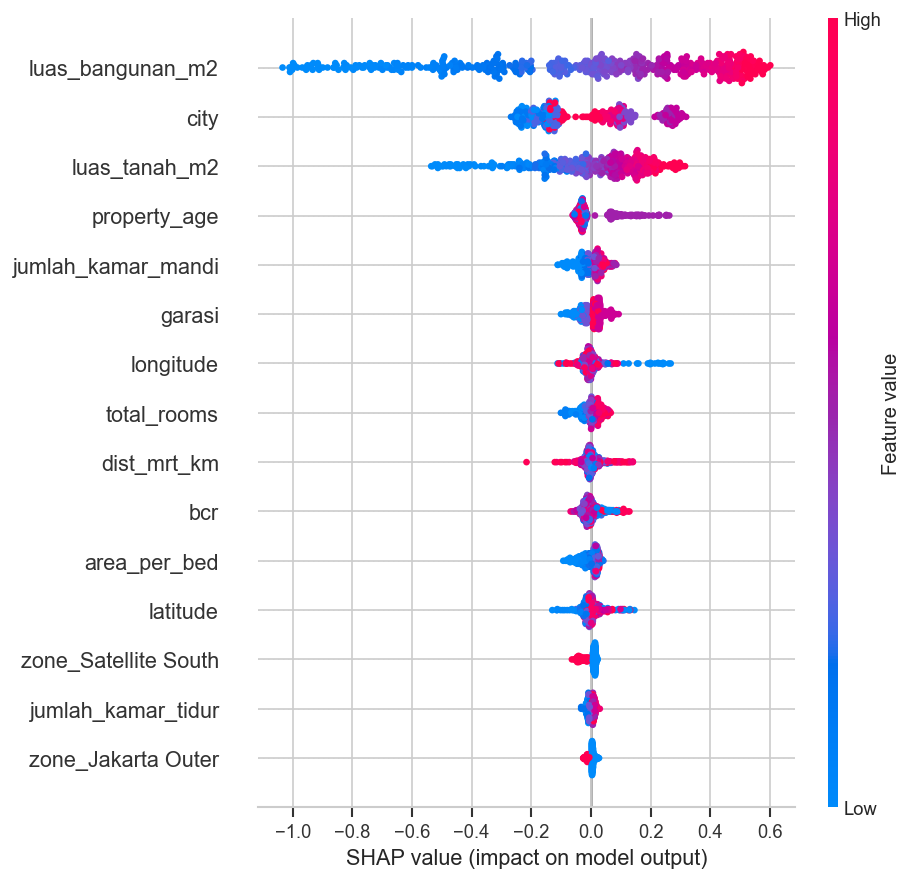

In [114]:
# ─── 9.2 SHAP Beeswarm Plot ──────────────────────────────────────────────────
# Each dot = one prediction. Color = feature value (red=high, blue=low).
# X-axis = SHAP value (impact on log-price prediction)

shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_names_transformed,
    plot_type="dot",
    max_display=15,
    show=True
)

### 9.3 SHAP Waterfall Plot (Single Prediction)

Predicted price: IDR 1,828,066,421  (1.83 Miliar)


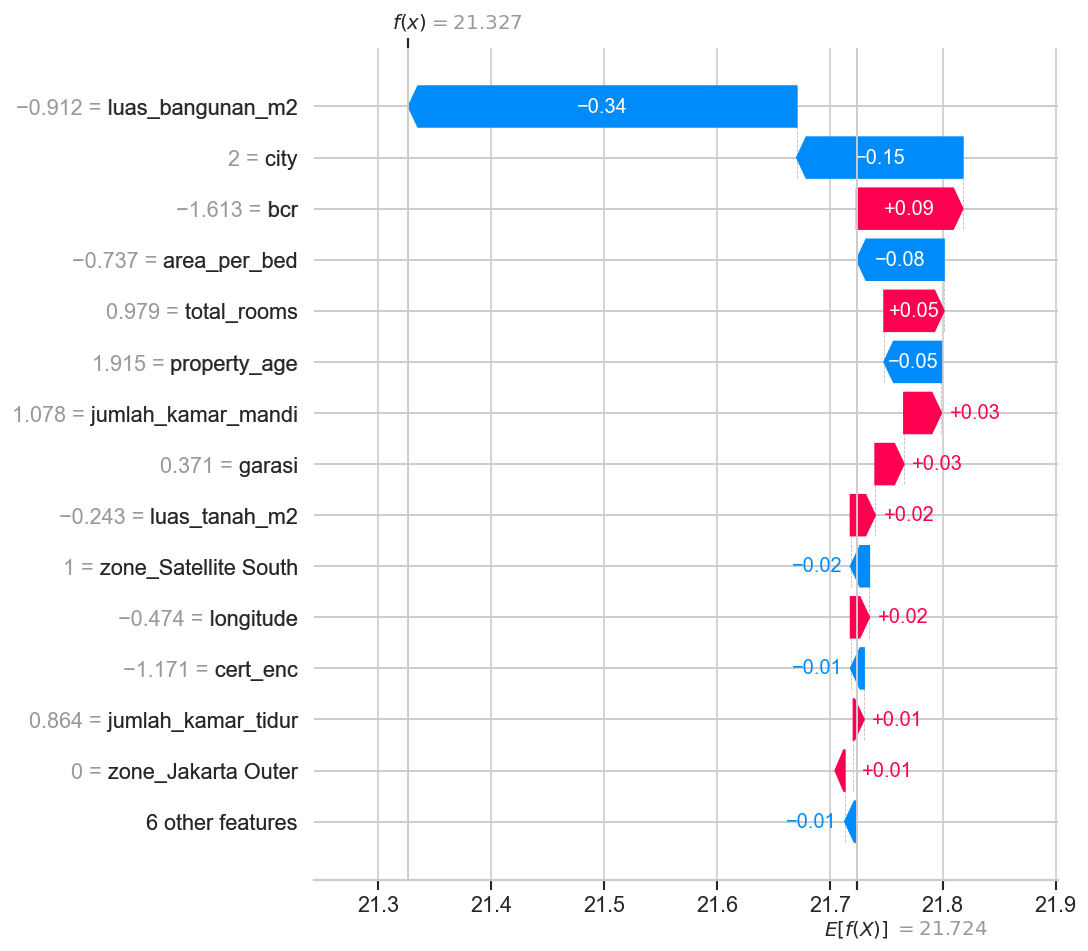

In [115]:
# ─── 9.3 SHAP Waterfall — Single Prediction Explanation ──────────────────────
# Explains how each feature pushes the prediction UP or DOWN from the base value.

SAMPLE_IDX = 0  # Change index to explain a different listing

shap_explanation = shap.Explanation(
    values         = shap_values[SAMPLE_IDX],
    base_values    = explainer.expected_value,
    data           = X_shap[SAMPLE_IDX],
    feature_names  = feature_names_transformed
)

predicted_log = best_model.predict(X_shap[[SAMPLE_IDX]])[0]
predicted_idr = np.expm1(predicted_log)
print(f"Predicted price: IDR {predicted_idr:,.0f}  ({predicted_idr/1e9:.2f} Miliar)")

shap.plots.waterfall(shap_explanation, max_display=15, show=True)

### 9.4 SHAP Dependence Plot (Key Features)

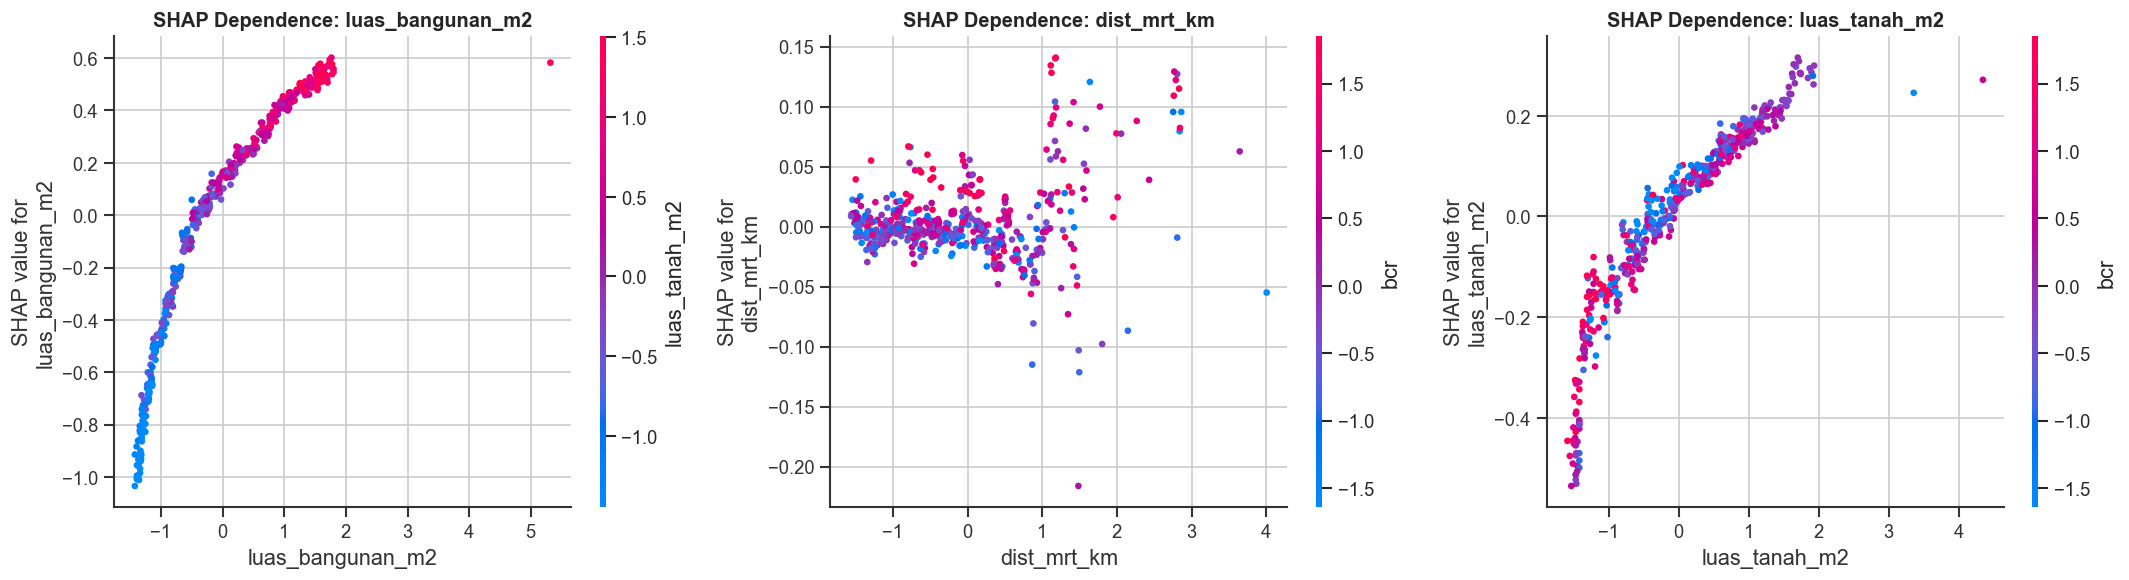

In [116]:
# ─── 9.4 SHAP Dependence Plots ────────────────────────────────────────────────
# Shows relationship between a feature value and its SHAP impact.
# Color = interaction effect with another feature (auto-selected by SHAP).

key_features = ["luas_bangunan_m2", "dist_mrt_km", "luas_tanah_m2"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, key_features):
    feat_idx = feature_names_transformed.index(feat)
    shap.dependence_plot(
        feat_idx, shap_values, X_shap,
        feature_names=feature_names_transformed,
        ax=ax, show=False
    )
    ax.set_title(f"SHAP Dependence: {feat}", fontweight="bold")

plt.tight_layout()
plt.show()

---
## 10. Model Serialization & Deployment Prep

### 10.1 Save Best Model & Preprocessing Pipeline

In [117]:
# ─── 10.1 Save Best Model ─────────────────────────────────────────────────────

joblib.dump(best_model, MODEL_PATH)
# Pipeline was already saved in Section 6.2

print(f"Best model saved → {MODEL_PATH}")
print(f"Pipeline saved   → {PIPELINE_PATH}")

Best model saved → D:\Analytic Projects 2026\Project Github\jakarta-house-predictor-system\models\best_model.pkl
Pipeline saved   → D:\Analytic Projects 2026\Project Github\jakarta-house-predictor-system\models\preprocessing_pipeline.pkl


### 10.2 Save SHAP Explainer

In [118]:
# ─── 10.2 Save SHAP Explainer ─────────────────────────────────────────────────

joblib.dump(explainer, EXPLAINER_PATH)
print(f"SHAP explainer saved → {EXPLAINER_PATH}")

SHAP explainer saved → D:\Analytic Projects 2026\Project Github\jakarta-house-predictor-system\models\shap_explainer.pkl


### 10.3 Save Feature Metadata

Already saved in Section 5.6. Verify it's complete.

In [119]:
# ─── 10.3 Verify Feature Metadata ────────────────────────────────────────────

with open(META_PATH) as f:
    meta = json.load(f)

print("Feature metadata keys:", list(meta.keys()))
print(f"All features: {meta['all_features']}")

Feature metadata keys: ['features_num', 'features_cat', 'features_ohe', 'all_features', 'target', 'kondisi_order', 'cert_order', 'zone_map', 'mrt_stations', 'current_year', 'cities']
All features: ['luas_bangunan_m2', 'luas_tanah_m2', 'jumlah_kamar_tidur', 'jumlah_kamar_mandi', 'garasi', 'property_age', 'dist_mrt_km', 'bath_bed_ratio', 'area_per_bed', 'bcr', 'total_rooms', 'kondisi_enc', 'cert_enc', 'latitude', 'longitude', 'city', 'zone_Jakarta Outer', 'zone_Satellite East', 'zone_Satellite South', 'zone_Satellite West']


### 10.4 Inference Sanity Check

Simulate the exact inference flow that `app.py` will use — ensuring pipeline + model load and predict correctly from scratch.

In [120]:
# ─── 10.4 Inference Sanity Check ─────────────────────────────────────────────

# Load artifacts fresh (as Streamlit would)
_model     = joblib.load(MODEL_PATH)
_pipeline  = joblib.load(PIPELINE_PATH)
_explainer = joblib.load(EXPLAINER_PATH)

with open(META_PATH) as f:
    _meta = json.load(f)


def predict_price(input_dict: dict) -> dict:
    """
    End-to-end inference function used by Streamlit app.

    Parameters
    ----------
    input_dict : dict — raw user inputs from the Streamlit form

    Returns
    -------
    dict with 'price_idr', 'price_miliar', 'shap_values', 'feature_names'
    """
    # ── Feature engineering (mirrors notebook steps) ──────────────────────────
    d = dict(input_dict)  # copy

    d["property_age"]  = CURRENT_YEAR - int(d.get("tahun_dibangun", 2010))
    d["bath_bed_ratio"] = d["jumlah_kamar_mandi"] / max(d["jumlah_kamar_tidur"], 1)
    d["area_per_bed"]   = d["luas_bangunan_m2"] / max(d["jumlah_kamar_tidur"], 1)
    d["bcr"]            = d["luas_bangunan_m2"] / max(d["luas_tanah_m2"], 1)
    d["total_rooms"]    = d["jumlah_kamar_tidur"] + d["jumlah_kamar_mandi"]
    d["kondisi_enc"]    = _meta["kondisi_order"].get(d.get("kondisi", "Bagus"), 2)
    d["cert_enc"]       = _meta["cert_order"].get(d.get("sertifikat", "SHM"), 2)

    # MRT distance
    d["dist_mrt_km"] = min_mrt_distance_km(d["latitude"], d["longitude"])

    # Zone OHE
    zone = _meta["zone_map"].get(d.get("city", ""), "Other")
    for col in _meta["features_ohe"]:
        zone_label = col.replace("zone_", "").replace("_", " ")
        d[col] = 1 if zone_label in zone else 0

    # Build DataFrame with exact feature order
    row = pd.DataFrame([{k: d.get(k, 0) for k in _meta["all_features"]}])

    # Preprocess
    X_inf = _pipeline.transform(row)

    # Predict
    log_pred = _model.predict(X_inf)[0]
    price    = np.expm1(log_pred)

    # SHAP
    sv       = _explainer.shap_values(X_inf)[0]

    return {
        "price_idr"    : price,
        "price_miliar" : price / 1e9,
        "shap_values"  : sv,
        "feature_names": _meta["all_features"],
        "base_value"   : _explainer.expected_value,
    }


# ── Test ──────────────────────────────────────────────────────────────────────
test_input = {
    "city"              : "Jakarta Selatan",
    "luas_bangunan_m2"  : 120.0,
    "luas_tanah_m2"     : 150.0,
    "jumlah_kamar_tidur": 3,
    "jumlah_kamar_mandi": 2,
    "garasi"            : 1,
    "tahun_dibangun"    : 2015,
    "sertifikat"        : "SHM",
    "kondisi"           : "Bagus",
    "latitude"          : -6.2607,
    "longitude"         : 106.7981,
}

result = predict_price(test_input)

print("=" * 50)
print("INFERENCE SANITY CHECK")
print("=" * 50)
print(f"Input             : {test_input['city']} | {test_input['luas_bangunan_m2']}m² | {test_input['jumlah_kamar_tidur']} BR")
print(f"Predicted Price   : IDR {result['price_idr']:,.0f}")
print(f"                  : {result['price_miliar']:.2f} Miliar IDR")
print(f"SHAP base value   : {result['base_value']:.4f}")
print(f"Top 3 SHAP drivers:")
top3 = np.argsort(np.abs(result['shap_values']))[-3:][::-1]
for i in top3:
    print(f"  {result['feature_names'][i]:<25}: SHAP = {result['shap_values'][i]:+.4f}")

print("\n✅ Inference pipeline working correctly — ready for Streamlit deployment!")

INFERENCE SANITY CHECK
Input             : Jakarta Selatan | 120.0m² | 3 BR
Predicted Price   : IDR 1,743,952,391
                  : 1.74 Miliar IDR
SHAP base value   : 21.7241
Top 3 SHAP drivers:
  luas_bangunan_m2         : SHAP = -0.4136
  city                     : SHAP = +0.2320
  luas_tanah_m2            : SHAP = -0.2093

✅ Inference pipeline working correctly — ready for Streamlit deployment!
